## Import libraries 

In [1]:
# Import libs
import numpy as np
import tensorflow as tf
from tensorflow import keras
import sys
import matplotlib.pyplot as plt
from sliding_window import create_feature_set
from sliding_window import plot_history


# Target coordinates

In [2]:
data_target = np.load('../../extracted_pdb_all_atom_backbone_iga_antigen.npy').astype(float)[:,1:]
data_target.shape

(5006, 19764)

In [3]:
train_feat = data_target[:100,:]/240
train_feat 

array([[0.537375  , 0.196625  , 0.429625  , ..., 0.60391667, 0.34495833,
        0.54720833],
       [0.53933333, 0.19404167, 0.41033333, ..., 0.60133333, 0.34941667,
        0.541875  ],
       [0.53395833, 0.18208333, 0.40508333, ..., 0.59625   , 0.3315    ,
        0.53325   ],
       ...,
       [0.54466667, 0.208375  , 0.31579167, ..., 0.595125  , 0.25420833,
        0.49908333],
       [0.545125  , 0.21225   , 0.31445833, ..., 0.592875  , 0.25341667,
        0.49675   ],
       [0.52725   , 0.20975   , 0.31408333, ..., 0.59425   , 0.25370833,
        0.49620833]])

In [4]:
train_feat.shape

(100, 19764)

In [5]:
train_LAB_48 = create_feature_set(train_feat)
train_LAB_48.shape

(164400, 48)

In [6]:
train_LAB_48[-1,:]

array([0.63591667, 0.269875  , 0.51704167, 0.63208333, 0.2735    ,
       0.51408333, 0.62658333, 0.27058333, 0.5125    , 0.62683333,
       0.26579167, 0.51075   , 0.62170833, 0.27341667, 0.51308333,
       0.61625   , 0.27058333, 0.512     , 0.61366667, 0.27254167,
       0.50666667, 0.61329167, 0.27758333, 0.50570833, 0.61204167,
       0.26870833, 0.503     , 0.61025   , 0.269875  , 0.49725   ,
       0.604125  , 0.26779167, 0.495625  , 0.60195833, 0.26879167,
       0.49095833, 0.60170833, 0.26466667, 0.49966667, 0.59608333,
       0.26241667, 0.50008333, 0.59375   , 0.25895833, 0.49558333,
       0.59425   , 0.25370833, 0.49620833])

In [7]:
data_bb = np.load('../../data_bb.npy')
data_bb.shape

(5006, 4941)

In [8]:
train_feat = data_bb[:100,:]
train_feat.shape

(100, 4941)

In [9]:
train_feat_12 = create_feature_set(train_feat,12,3)
train_feat_12.shape

(164400, 12)

In [11]:
train_feat_12.shape[0] - train_LAB_48.shape[0]

0

In [10]:
del data_bb, data_target

In [16]:
32/2

16.0

In [21]:

def create_model_1(input_shape, num_outputs):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Dense(256, activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(16, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    #-----------------------------------------------------------------------------------

    x = tf.keras.layers.Dense(8, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(16, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(32, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    output = tf.keras.layers.Dense(num_outputs, activation='linear')(x)
  
    
    model = tf.keras.Model(inputs=inputs, outputs=output)
    return model



In [22]:
# Example usage:
input_shape = (12,)  # Example input shape, adjust based on your actual data
output_num = 48  # Example number of bins, adjust based on your actual data

# Create the model
model = create_model_1(input_shape, output_num)

In [23]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 12)]              0         
                                                                 
 dense_9 (Dense)             (None, 256)               3328      
                                                                 
 batch_normalization_8 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dense_10 (Dense)            (None, 128)               32896     
                                                                 
 batch_normalization_9 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dropout_7 (Dropout)         (None, 128)               0   

In [32]:
t = 4096*2
t


8192

In [41]:

def create_model_2(input_shape, num_outputs):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Dense(2048, activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Dense(1024, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

     
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

     
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    #-----------------------------------------------------------------------------------

    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    output = tf.keras.layers.Dense(num_outputs, activation='linear')(x)
  
    
    model = tf.keras.Model(inputs=inputs, outputs=output)
    return model



In [42]:
# Example usage:
input_shape = (12,)  # Example input shape, adjust based on your actual data
output_num = 48  # Example number of bins, adjust based on your actual data

# Create the model
model = create_model_2(input_shape, output_num)

In [43]:
model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 12)]              0         
                                                                 
 dense_35 (Dense)            (None, 2048)              26624     
                                                                 
 batch_normalization_31 (Ba  (None, 2048)              8192      
 tchNormalization)                                               
                                                                 
 dense_36 (Dense)            (None, 1024)              2098176   
                                                                 
 batch_normalization_32 (Ba  (None, 1024)              4096      
 tchNormalization)                                               
                                                                 
 dropout_27 (Dropout)        (None, 1024)              0   

In [44]:
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.001), loss='mse',metrics=['mae',keras.metrics.RootMeanSquaredError()])


In [45]:
history = model.fit(
    train_feat_12,train_LAB_48,
    epochs =10,
    shuffle = True

)

Epoch 1/10
5138/5138 [==============================] - 88s 17ms/step - loss: 0.0262 - mae: 0.0707 - root_mean_squared_error: 0.1619
Epoch 2/10
5138/5138 [==============================] - 89s 17ms/step - loss: 0.0015 - mae: 0.0304 - root_mean_squared_error: 0.0393
Epoch 3/10
5138/5138 [==============================] - 89s 17ms/step - loss: 0.0013 - mae: 0.0278 - root_mean_squared_error: 0.0360
Epoch 4/10
5138/5138 [==============================] - 86s 17ms/step - loss: 0.0012 - mae: 0.0266 - root_mean_squared_error: 0.0345
Epoch 5/10
5138/5138 [==============================] - 84s 16ms/step - loss: 0.0011 - mae: 0.0258 - root_mean_squared_error: 0.0335
Epoch 6/10
5138/5138 [==============================] - 93s 18ms/step - loss: 0.0011 - mae: 0.0256 - root_mean_squared_error: 0.0332
Epoch 7/10
5138/5138 [==============================] - 83s 16ms/step - loss: 0.0010 - mae: 0.0250 - root_mean_squared_error: 0.0323
Epoch 8/10
5138/5138 [==============================] - 113s 22ms/ste

In [2]:
from tensorflow.keras import layers, models, callbacks, regularizers



In [3]:
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [4]:
callbacks=[reduce_lr]

1e-06

old shape: (5006, 19765)

In [8]:
data_feature1 = data_feature[0:2,:]

In [9]:
np.savetxt("foo.csv", data_feature1, delimiter=",")

In [2]:
2340*3

7020

In [ ]:
import tensorflow as tf

def create_model_LeakyRELU(input_shape, num_outputs, alpha=0.2, activation_layer=tf.keras.layers.LeakyReLU):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Dense(2048, kernel_initializer='he_normal')(inputs)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Dense(1024, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(512, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(256, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(256, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(128, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(128, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(64, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    output = tf.keras.layers.Dense(num_outputs, activation='linear')(x)

    model = tf.keras.Model(inputs=inputs, outputs=output)
    return model

# Example input shape and output number, adjust based on your actual data
input_shape = (12,)
output_num = 48

# Alpha value for LeakyReLU
alpha_value = 0.3  # You can adjust this as needed

# Create the model
model = create_model_LeakyRELU(input_shape, output_num, alpha=alpha_value)

# Compile the model with built-in RMSE and MAE metrics
model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(), 'mae'])

# Define the ModelCheckpoint callback
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.h5',   # Path where the best model will be saved
    monitor='val_loss',         # Metric to monitor
    save_best_only=True,        # Save only the best model
    save_weights_only=False,    # Save the full model
    mode='min',                 # Minimize the monitored metric
    verbose=1                   # Verbose output when saving the model
)

# Train the model with the callback
history = model.fit(
    train_data,                 # Replace with your training data
    train_labels,               # Replace with your training labels
    validation_data=(val_data, val_labels),  # Replace with your validation data and labels
    epochs=50,                  # Number of epochs
    batch_size=32,              # Batch size
    callbacks=[checkpoint_callback]  # Add the checkpoint callback
)


In [3]:
24*3

72

In [3]:
10042/60


167.36666666666667

In [4]:
167.36666666666667/60

2.7894444444444444

In [7]:
2.8*25

70.0

In [6]:
280/24

11.666666666666666

In [8]:
24*3

72

In [20]:
number_beads= {
 'CYS':[1,[2]],
 'ALA':[0,[3]],
 'MET':[1,[2]],
 'ASP':[1,[4]],
 'ASN':[1,[3]],
 'ARG':[2,[2,4]],
 'GLN':[1,[3]],
 'GLU':[1,[4]],
 'GLY':[0,[3]],
 'HIS':[3,[1,3,3]],
 'ILE':[1,[1]],
 'LEU':[1,[1]],
 'LYS':[2,[1,4]],
 'PHE':[3,[1,1,1]],
 'PRO':[1,[1]],
 'SER':[1,[3]],
 'THR':[1,[3]],
 'TRP':[4,[1,3,1,1]],
 'TYR':[3,[1,1,3]],
 'VAL':[1,[1]]
 }

In [27]:
number_beads

{'CYS': [1, [2]],
 'ALA': [0, [3]],
 'MET': [1, [2]],
 'ASP': [1, [4]],
 'ASN': [1, [3]],
 'ARG': [2, [2, 4]],
 'GLN': [1, [3]],
 'GLU': [1, [4]],
 'GLY': [0, [3]],
 'HIS': [3, [1, 3, 3]],
 'ILE': [1, [1]],
 'LEU': [1, [1]],
 'LYS': [2, [1, 4]],
 'PHE': [3, [1, 1, 1]],
 'PRO': [1, [1]],
 'SER': [1, [3]],
 'THR': [1, [3]],
 'TRP': [4, [1, 3, 1, 1]],
 'TYR': [3, [1, 1, 3]],
 'VAL': [1, [1]]}

In [22]:
len(number_beads.keys())

20

In [25]:
no_Atoms= {
 'CYS':[2,[0]],
 'ALA':[1,[0]],
 'MET':[4,[0]],
 'ASP':[4,[0]],
 'ASN':[4,[0]],
 'ARG':[7,['0_3','3_8']],
 'GLN':[5,[0]],
 'GLU':[5,[0]],
 'GLY':[0,[0]],
 'HIS':[6,['0_2','2_4','4_6']],
 'ILE':[4,[0]],
 'LEU':[4,[0]],
 'LYS':[5,['0_3','3_5']],
 'PHE':[7,['0_3','3_5','5_7']],
 'PRO':[3,[0]],
 'SER':[2,[0]],
 'THR':[3,[0]],
 'TRP':[10,['0,1,9','2_5','7,8','5,6']],
 'TYR':[8,['0_3','3_6','6_8']],
 'VAL':[3,[0]]
 }

In [26]:
no_Atoms

{'CYS': [2, [0]],
 'ALA': [1, [0]],
 'MET': [4, [0]],
 'ASP': [4, [0]],
 'ASN': [4, [0]],
 'ARG': [7, ['0_3', '3_8']],
 'GLN': [5, [0]],
 'GLU': [5, [0]],
 'GLY': [0, [0]],
 'HIS': [6, ['0_2', '2_4', '4_6']],
 'ILE': [4, [0]],
 'LEU': [4, [0]],
 'LYS': [5, ['0_3', '3_5']],
 'PHE': [7, ['0_3', '3_5', '5_7']],
 'PRO': [3, [0]],
 'SER': [2, [0]],
 'THR': [3, [0]],
 'TRP': [10, ['0,1,9', '2_5', '7,8', '5,6']],
 'TYR': [8, ['0_3', '3_6', '6_8']],
 'VAL': [3, [0]]}

In [28]:
import re

In [35]:
filenames = ["cluster_8_SC.npy", "cluster_1_SC.npy"]

In [30]:
pattern = r"cluster_(\d+)_SC.npy"
numbers = [int(re.search(pattern, filename).group(1)) for filename in filenames]


In [42]:
filename = "cluster_99_SC.npy"


pattern = r"cluster_(\d+)_SC.npy"
number = int(re.search(pattern, cluster_file).group(1))
number

99

In [43]:
12 24 48

48

In [ ]:
sed 's/HID/HIS/g' cluster_backbone_96/frame_111190.pdb > temp.pdb
sed 's/CLEUA/LEU A/g' temp.pdb > temp2.pdb
rm $output_file
sed 's/NSERB/SER B/g' temp2.pdb > temp3.pdb
sed 's/CLEUB/LEU B/g' temp3.pdb > temp4.pdb
sed 's/NSERC/SER C/g' temp4.pdb > temp5.pdb
sed 's/CLEUC/LEU C/g' temp5.pdb > temp6.pdb
sed 's/ASH/ASP/g' temp6.pdb > temp7.pdb
sed 's/CYM/CYS/g' temp7.pdb > temp8.pdb
sed 's/HIP/HIS/g' temp8.pdb > temp9.pdb
sed 's/NSERA/SER A/g' temp9.pdb > temp10.pdb

In [44]:

(14*5)/4.8

14.583333333333334

In [45]:
14/5

2.8

In [46]:
3*4.8

14.399999999999999

1

In [50]:
1 - 7




7.0

In [54]:
73/14

5.214285714285714

In [52]:
800/80


10.0

In [53]:
75/14

5.357142857142857

In [55]:
907/30.4


29.835526315789476

In [57]:
32*2

64

In [2]:
import numpy as np
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
with open('training_history_winS_2.json', 'r') as f:
    history_dict_2 = json.load(f)

In [4]:
with open('training_history_winS_4.json', 'r') as f:
    history_dict_4 = json.load(f)

In [5]:
with open('training_history_winS_8.json', 'r') as f:
    history_dict_8 = json.load(f)

In [77]:
with open('training_history_winS_16.json', 'r') as f:
    history_dict_16 = json.load(f)


with open('training_history_winS_32.json', 'r') as f:
    history_dict_32 = json.load(f)

with open('training_history_winS_64.json', 'r') as f:
    history_dict_64 = json.load(f)

In [88]:
with open('training_history_LeakyRelu.jsontraining_history_LeakyRelu.json', 'r') as f:
    history_dict_SWISH = json.load(f)

with open('training_history_LeakyRelu.json', 'r') as f:
    history_dict_RELU = json.load(f)

In [4]:
def load_history(json_path, model_name):
    with open(json_path, 'r') as f:
        history = json.load(f)
    
    # Create a DataFrame from history with model name added
    df = pd.DataFrame(history)
    df['epoch'] = df.index + 1
    df = df.melt(id_vars=['epoch'], var_name='metric', value_name='value')
    df['model'] = model_name
    return df

In [80]:
model1 = load_history('training_history_winS_2.json','Win 2')
model2 = load_history('training_history_winS_4.json','Win 4')
model3 = load_history('training_history_winS_8.json','Win 8')
model4 = load_history('training_history_winS_16.json','Win 16')
model5 = load_history('training_history_winS_32.json','Win 32')
model6 = load_history('training_history_winS_64.json','Win 64')

In [5]:
model_SWISH =  load_history('training_history_LeakyRelu.json','SWISH')
model_RELU =  load_history('training_history_LeakyRelu.json','Leaky RELU')

In [82]:
model6

,epoch,metric,value,model
0,1,loss,0.002700,Win 64
1,2,loss,0.001798,Win 64
2,3,loss,0.001783,Win 64
3,4,loss,0.001773,Win 64
4,5,loss,0.001765,Win 64
...,...,...,...,...
295,46,val_root_mean_squared_error,0.142119,Win 64
296,47,val_root_mean_squared_error,0.140940,Win 64
297,48,val_root_mean_squared_error,0.140486,Win 64
298,49,val_root_mean_squared_error,0.142351,Win 64


In [86]:
# Combine all histories into one DataFrame
all_models = pd.concat([model1, model2, model3,model4,model5,model6])
# Filter to include only RMSE metrics if there are multiple types
all_models = all_models[all_models['metric'].str.contains('val_root_mean_squared_error', case=False)]

In [6]:
loss_models = pd.concat([model_RELU,model_SWISH])
loss_models = loss_models[loss_models['metric'].str.contains('root_mean_squared_error', case=False)]


In [84]:
all_models = all_models[all_models['metric']=='root_mean_squared_error']

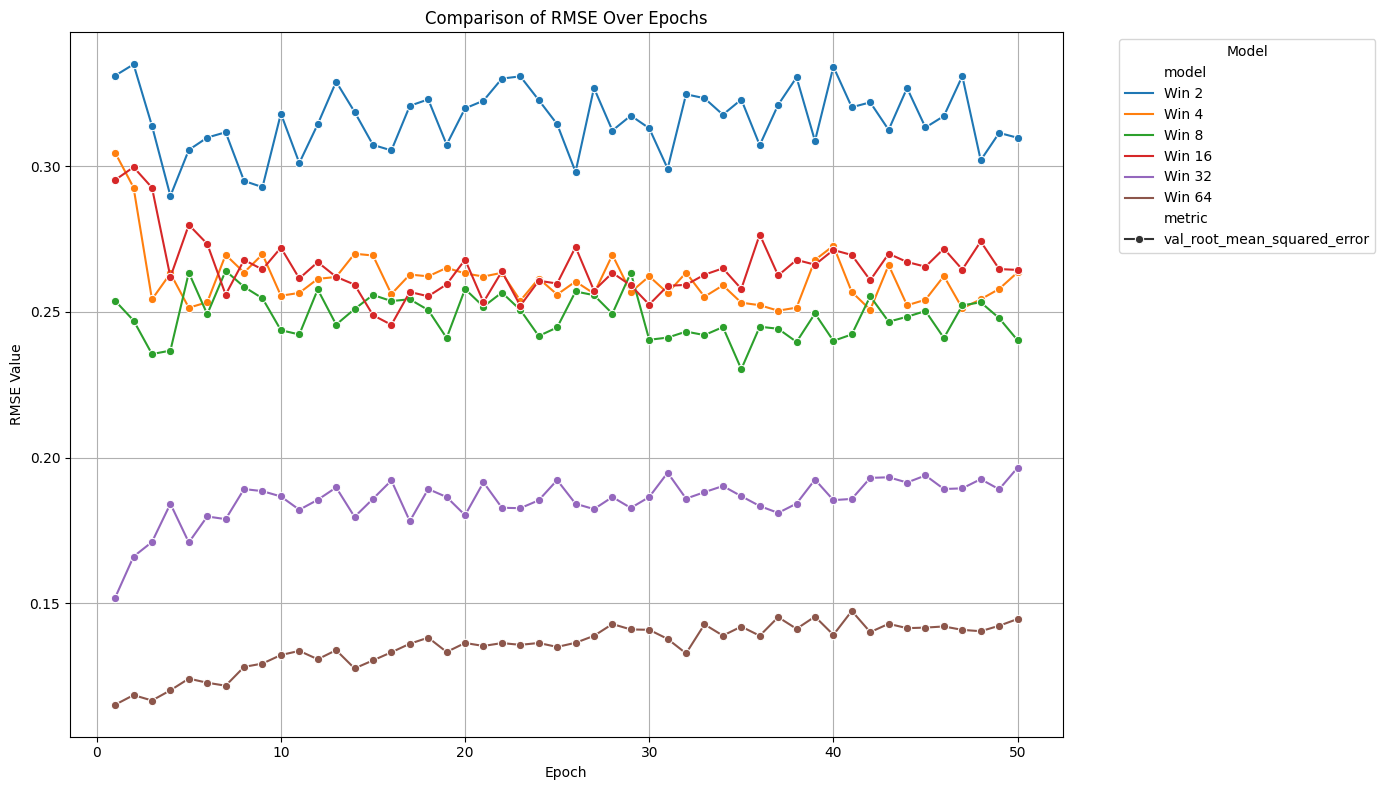

In [87]:
# Plot the RMSE comparison
plt.figure(figsize=(14, 8))
sns.lineplot(data=all_models, x='epoch', y='value', hue='model', style='metric', markers=True)

# Customize plot
plt.title('Comparison of RMSE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('RMSE Value')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

In [8]:
loss_models_SWISH = loss_models[loss_models['model']=='SWISH'] 

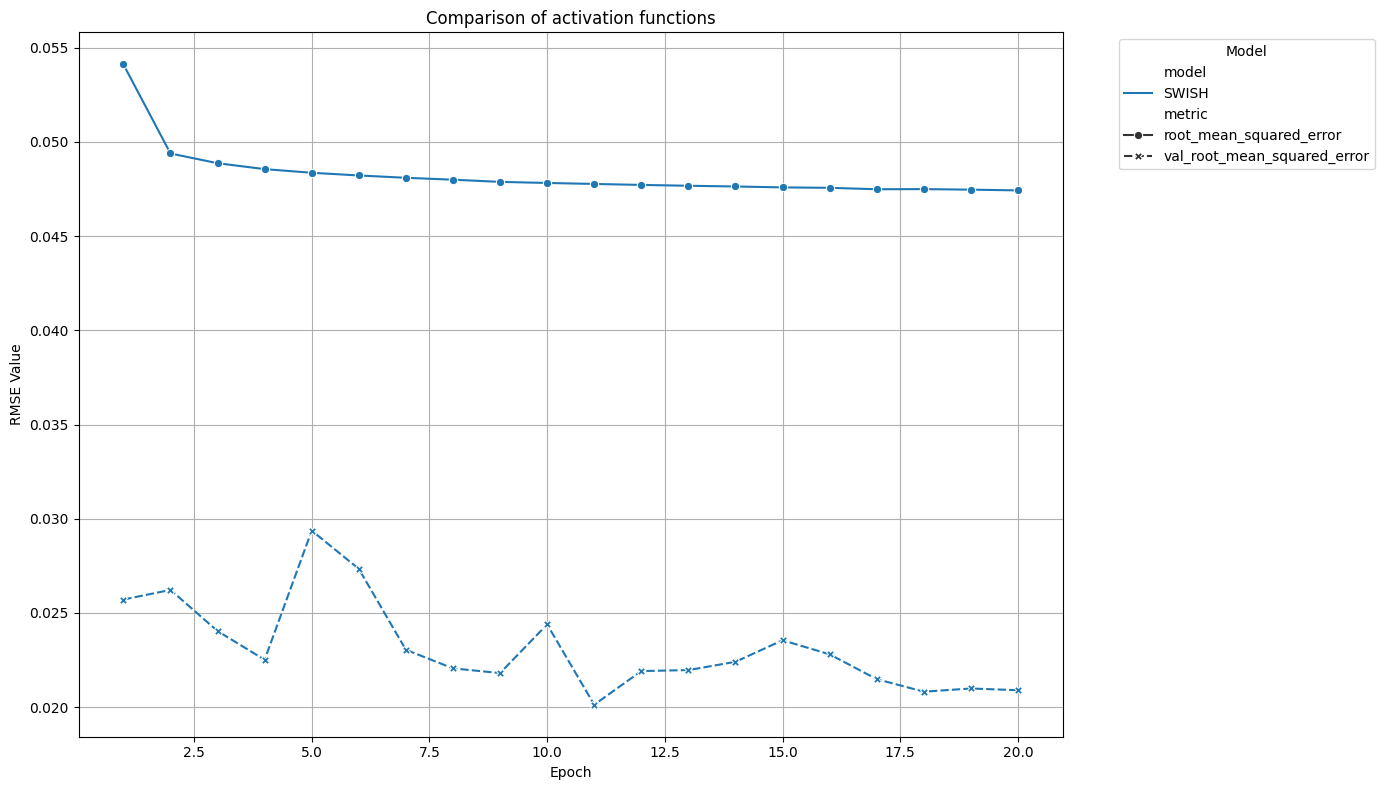

In [9]:
# Plot the RMSE comparison
plt.figure(figsize=(14, 8))
sns.lineplot(data=loss_models_SWISH, x='epoch', y='value', hue='model', style='metric', markers=True)

# Customize plot
plt.title('Comparison of activation functions')
plt.xlabel('Epoch')
plt.ylabel('RMSE Value')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

In [41]:
from Bio.SubsMat import MatrixInfo

ModuleNotFoundError: No module named 'Bio'

In [16]:
BLOSUM60 = {
'A':'4 -1 -1 -2  0 -1 -1  0 -2 -1 -1 -1 -1 -2 -1  1  0 -3 -2  0',
'R': '-1  5  0 -1 -3  1  0 -2  0 -3 -2  2 -1 -3 -2 -1 -1 -3 -2 -2',
'N': '-1  0  6  1 -2  0  0  0  1 -3 -3  0 -2 -3 -2  1  0 -4 -2 -3',
'D': '-2 -1  1  6 -3  0  2 -1 -1 -3 -3 -1 -3 -3 -1  0 -1 -4 -3 -3',
'C':' 0 -3 -2 -3  9 -3 -3 -2 -3 -1 -1 -3 -1 -2 -3 -1 -1 -2 -2 -1',
'Q': '-1  1  0  0 -3  5  2 -2  1 -3 -2  1  0 -3 -1  0 -1 -2 -1 -2',
'E': '-1  0  0  2 -3  2  5 -2  0 -3 -3  1 -2 -3 -1  0 -1 -3 -2 -2',
'G':  '0 -2  0 -1 -2 -2 -2  6 -2 -3 -4 -1 -2 -3 -2  0 -2 -2 -3 -3',
'H': '-2  0  1 -1 -3  1  0 -2  7 -3 -3 -1 -1 -1 -2 -1 -2 -2  2 -3',
'I': '-1 -3 -3 -3 -1 -3 -3 -3 -3  4  2 -3  1  0 -3 -2 -1 -2 -1  3',
'L': '-1 -2 -3 -3 -1 -2 -3 -4 -3  2  4 -2  2  0 -3 -2 -1 -2 -1  1',
'K': '-1  2  0 -1 -3  1  1 -1 -1 -3 -2  4 -1 -3 -1  0 -1 -3 -2 -2',
'M': '-1 -1 -2 -3 -1  0 -2 -2 -1  1  2 -1  5  0 -2 -1 -1 -1 -1  1',
'F': '-2 -3 -3 -3 -2 -3 -3 -3 -1  0  0 -3  0  6 -4 -2 -2  1  3 -1',
'P': '-1 -2 -2 -1 -3 -1 -1 -2 -2 -3 -3 -1 -2 -4  7 -1 -1 -4 -3 -2',
'S':  '1 -1  1  0 -1  0  0  0 -1 -2 -2  0 -1 -2 -1  4  1 -3 -2 -2',
'T':  '0 -1  0 -1 -1 -1 -1 -2 -2 -1 -1 -1 -1 -2 -1  1  4 -2 -2  0',
'W': '-3 -3 -4 -4 -2 -2 -3 -2 -2 -2 -2 -3 -1  1 -4 -3 -2 10  2 -3',
'Y': '-2 -2 -2 -3 -2 -1 -2 -3  2 -1 -1 -2 -1  3 -3 -2 -2  2  6 -1',
'V':  '0 -2 -3 -3 -1 -2 -2 -3 -3  3  1 -2  1 -1 -2 -2  0 -3 -1  4'

}
BLOSUM60

{'A': '4 -1 -1 -2  0 -1 -1  0 -2 -1 -1 -1 -1 -2 -1  1  0 -3 -2  0',
 'R': '-1  5  0 -1 -3  1  0 -2  0 -3 -2  2 -1 -3 -2 -1 -1 -3 -2 -2',
 'N': '-1  0  6  1 -2  0  0  0  1 -3 -3  0 -2 -3 -2  1  0 -4 -2 -3',
 'D': '-2 -1  1  6 -3  0  2 -1 -1 -3 -3 -1 -3 -3 -1  0 -1 -4 -3 -3',
 'C': ' 0 -3 -2 -3  9 -3 -3 -2 -3 -1 -1 -3 -1 -2 -3 -1 -1 -2 -2 -1',
 'Q': '-1  1  0  0 -3  5  2 -2  1 -3 -2  1  0 -3 -1  0 -1 -2 -1 -2',
 'E': '-1  0  0  2 -3  2  5 -2  0 -3 -3  1 -2 -3 -1  0 -1 -3 -2 -2',
 'G': '0 -2  0 -1 -2 -2 -2  6 -2 -3 -4 -1 -2 -3 -2  0 -2 -2 -3 -3',
 'H': '-2  0  1 -1 -3  1  0 -2  7 -3 -3 -1 -1 -1 -2 -1 -2 -2  2 -3',
 'I': '-1 -3 -3 -3 -1 -3 -3 -3 -3  4  2 -3  1  0 -3 -2 -1 -2 -1  3',
 'L': '-1 -2 -3 -3 -1 -2 -3 -4 -3  2  4 -2  2  0 -3 -2 -1 -2 -1  1',
 'K': '-1  2  0 -1 -3  1  1 -1 -1 -3 -2  4 -1 -3 -1  0 -1 -3 -2 -2',
 'M': '-1 -1 -2 -3 -1  0 -2 -2 -1  1  2 -1  5  0 -2 -1 -1 -1 -1  1',
 'F': '-2 -3 -3 -3 -2 -3 -3 -3 -1  0  0 -3  0  6 -4 -2 -2  1  3 -1',
 'P': '-1 -2 -2 -1 -3 -1 -1 -2 -2 -3

In [65]:
counter=1
for k in BLOSUM60.keys():
    print(f'"{k}":',[int(i) for i in BLOSUM60[k].split( )],',')
    BLOSUM60[k] = [int(i) for i in BLOSUM60[k].split( )]

    counter+=1

"A": [4, -1, -1, -2, 0, -1, -1, 0, -2, -1, -1, -1, -1, -2, -1, 1, 0, -3, -2, 0] ,
"R": [-1, 5, 0, -1, -3, 1, 0, -2, 0, -3, -2, 2, -1, -3, -2, -1, -1, -3, -2, -2] ,
"N": [-1, 0, 6, 1, -2, 0, 0, 0, 1, -3, -3, 0, -2, -3, -2, 1, 0, -4, -2, -3] ,
"D": [-2, -1, 1, 6, -3, 0, 2, -1, -1, -3, -3, -1, -3, -3, -1, 0, -1, -4, -3, -3] ,
"C": [0, -3, -2, -3, 9, -3, -3, -2, -3, -1, -1, -3, -1, -2, -3, -1, -1, -2, -2, -1] ,
"Q": [-1, 1, 0, 0, -3, 5, 2, -2, 1, -3, -2, 1, 0, -3, -1, 0, -1, -2, -1, -2] ,
"E": [-1, 0, 0, 2, -3, 2, 5, -2, 0, -3, -3, 1, -2, -3, -1, 0, -1, -3, -2, -2] ,
"G": [0, -2, 0, -1, -2, -2, -2, 6, -2, -3, -4, -1, -2, -3, -2, 0, -2, -2, -3, -3] ,
"H": [-2, 0, 1, -1, -3, 1, 0, -2, 7, -3, -3, -1, -1, -1, -2, -1, -2, -2, 2, -3] ,
"I": [-1, -3, -3, -3, -1, -3, -3, -3, -3, 4, 2, -3, 1, 0, -3, -2, -1, -2, -1, 3] ,
"L": [-1, -2, -3, -3, -1, -2, -3, -4, -3, 2, 4, -2, 2, 0, -3, -2, -1, -2, -1, 1] ,
"K": [-1, 2, 0, -1, -3, 1, 1, -1, -1, -3, -2, 4, -1, -3, -1, 0, -1, -3, -2, -2] ,
"M": [-1, -1, -2

In [57]:
BLOSUM60['A'], len(BLOSUM60['A'])

([4, -1, -1, -2, 0, -1, -1, 0, -2, -1, -1, -1, -1, -2, -1, 1, 0, -3, -2, 0],
 20)

In [66]:
{"A": [4, -1, -1, -2, 0, -1, -1, 0, -2, -1, -1, -1, -1, -2, -1, 1, 0, -3, -2, 0] ,
"R": [-1, 5, 0, -1, -3, 1, 0, -2, 0, -3, -2, 2, -1, -3, -2, -1, -1, -3, -2, -2] ,
"N": [-1, 0, 6, 1, -2, 0, 0, 0, 1, -3, -3, 0, -2, -3, -2, 1, 0, -4, -2, -3] ,
"D": [-2, -1, 1, 6, -3, 0, 2, -1, -1, -3, -3, -1, -3, -3, -1, 0, -1, -4, -3, -3] ,
"C": [0, -3, -2, -3, 9, -3, -3, -2, -3, -1, -1, -3, -1, -2, -3, -1, -1, -2, -2, -1] ,
"Q": [-1, 1, 0, 0, -3, 5, 2, -2, 1, -3, -2, 1, 0, -3, -1, 0, -1, -2, -1, -2] ,
"E": [-1, 0, 0, 2, -3, 2, 5, -2, 0, -3, -3, 1, -2, -3, -1, 0, -1, -3, -2, -2] ,
"G": [0, -2, 0, -1, -2, -2, -2, 6, -2, -3, -4, -1, -2, -3, -2, 0, -2, -2, -3, -3] ,
"H": [-2, 0, 1, -1, -3, 1, 0, -2, 7, -3, -3, -1, -1, -1, -2, -1, -2, -2, 2, -3] ,
"I": [-1, -3, -3, -3, -1, -3, -3, -3, -3, 4, 2, -3, 1, 0, -3, -2, -1, -2, -1, 3] ,
"L": [-1, -2, -3, -3, -1, -2, -3, -4, -3, 2, 4, -2, 2, 0, -3, -2, -1, -2, -1, 1] ,
"K": [-1, 2, 0, -1, -3, 1, 1, -1, -1, -3, -2, 4, -1, -3, -1, 0, -1, -3, -2, -2] ,
"M": [-1, -1, -2, -3, -1, 0, -2, -2, -1, 1, 2, -1, 5, 0, -2, -1, -1, -1, -1, 1] ,
"F": [-2, -3, -3, -3, -2, -3, -3, -3, -1, 0, 0, -3, 0, 6, -4, -2, -2, 1, 3, -1] ,
"P": [-1, -2, -2, -1, -3, -1, -1, -2, -2, -3, -3, -1, -2, -4, 7, -1, -1, -4, -3, -2] ,
"S": [1, -1, 1, 0, -1, 0, 0, 0, -1, -2, -2, 0, -1, -2, -1, 4, 1, -3, -2, -2] ,
"T": [0, -1, 0, -1, -1, -1, -1, -2, -2, -1, -1, -1, -1, -2, -1, 1, 4, -2, -2, 0] ,
"W": [-3, -3, -4, -4, -2, -2, -3, -2, -2, -2, -2, -3, -1, 1, -4, -3, -2, 10, 2, -3] ,
"Y": [-2, -2, -2, -3, -2, -1, -2, -3, 2, -1, -1, -2, -1, 3, -3, -2, -2, 2, 6, -1] ,
"V": [0, -2, -3, -3, -1, -2, -2, -3, -3, 3, 1, -2, 1, -1, -2, -2, 0, -3, -1, 4] }

{'A': [4,
  -1,
  -1,
  -2,
  0,
  -1,
  -1,
  0,
  -2,
  -1,
  -1,
  -1,
  -1,
  -2,
  -1,
  1,
  0,
  -3,
  -2,
  0],
 'R': [-1,
  5,
  0,
  -1,
  -3,
  1,
  0,
  -2,
  0,
  -3,
  -2,
  2,
  -1,
  -3,
  -2,
  -1,
  -1,
  -3,
  -2,
  -2],
 'N': [-1, 0, 6, 1, -2, 0, 0, 0, 1, -3, -3, 0, -2, -3, -2, 1, 0, -4, -2, -3],
 'D': [-2,
  -1,
  1,
  6,
  -3,
  0,
  2,
  -1,
  -1,
  -3,
  -3,
  -1,
  -3,
  -3,
  -1,
  0,
  -1,
  -4,
  -3,
  -3],
 'C': [0,
  -3,
  -2,
  -3,
  9,
  -3,
  -3,
  -2,
  -3,
  -1,
  -1,
  -3,
  -1,
  -2,
  -3,
  -1,
  -1,
  -2,
  -2,
  -1],
 'Q': [-1, 1, 0, 0, -3, 5, 2, -2, 1, -3, -2, 1, 0, -3, -1, 0, -1, -2, -1, -2],
 'E': [-1, 0, 0, 2, -3, 2, 5, -2, 0, -3, -3, 1, -2, -3, -1, 0, -1, -3, -2, -2],
 'G': [0,
  -2,
  0,
  -1,
  -2,
  -2,
  -2,
  6,
  -2,
  -3,
  -4,
  -1,
  -2,
  -3,
  -2,
  0,
  -2,
  -2,
  -3,
  -3],
 'H': [-2,
  0,
  1,
  -1,
  -3,
  1,
  0,
  -2,
  7,
  -3,
  -3,
  -1,
  -1,
  -1,
  -2,
  -1,
  -2,
  -2,
  2,
  -3],
 'I': [-1,
  -3,
  -3,
  -3,
  -1,
 

In [76]:
BLOSUM60[three_to_one['ALA']]

[4, -1, -1, -2, 0, -1, -1, 0, -2, -1, -1, -1, -1, -2, -1, 1, 0, -3, -2, 0]

In [75]:
three_to_one = {
    'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F', 'GLY': 'G',
    'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L', 'MET': 'M', 'ASN': 'N',
    'PRO': 'P', 'GLN': 'Q', 'ARG': 'R', 'SER': 'S', 'THR': 'T', 'VAL': 'V',
    'TRP': 'W', 'TYR': 'Y'
}


In [10]:
1923/60

32.05

In [11]:
amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
aa_to_idx = {aa: idx for idx, aa in enumerate(amino_acids)}
aa_to_idx

{'A': 0,
 'C': 1,
 'D': 2,
 'E': 3,
 'F': 4,
 'G': 5,
 'H': 6,
 'I': 7,
 'K': 8,
 'L': 9,
 'M': 10,
 'N': 11,
 'P': 12,
 'Q': 13,
 'R': 14,
 'S': 15,
 'T': 16,
 'V': 17,
 'W': 18,
 'Y': 19}

In [12]:
from tensorflow.keras.layers import Embedding

In [13]:
# Define the embedding layer for 20 amino acids
embedding_dim = 16  # This is the size of the embedding vector for each amino acid
embedding_layer = Embedding(input_dim=len(amino_acids), output_dim=embedding_dim)


In [15]:
# Example sequence of amino acid indices (e.g., ['A', 'C', 'D', 'E'])
sequence_indices = [aa_to_idx[aa] for aa in ['A', 'C', 'D', 'E']]
sequence_indices = np.array(sequence_indices)
# Get the embeddings for the sequence
amino_acid_embeddings = embedding_layer(sequence_indices)

In [19]:
amino_acids = list(BLOSUM60.keys())
blosum_matrix = np.array([list(map(int, BLOSUM60[aa].split())) for aa in amino_acids])
blosum_matrix

array([[ 4, -1, -1, -2,  0, -1, -1,  0, -2, -1, -1, -1, -1, -2, -1,  1,
         0, -3, -2,  0],
       [-1,  5,  0, -1, -3,  1,  0, -2,  0, -3, -2,  2, -1, -3, -2, -1,
        -1, -3, -2, -2],
       [-1,  0,  6,  1, -2,  0,  0,  0,  1, -3, -3,  0, -2, -3, -2,  1,
         0, -4, -2, -3],
       [-2, -1,  1,  6, -3,  0,  2, -1, -1, -3, -3, -1, -3, -3, -1,  0,
        -1, -4, -3, -3],
       [ 0, -3, -2, -3,  9, -3, -3, -2, -3, -1, -1, -3, -1, -2, -3, -1,
        -1, -2, -2, -1],
       [-1,  1,  0,  0, -3,  5,  2, -2,  1, -3, -2,  1,  0, -3, -1,  0,
        -1, -2, -1, -2],
       [-1,  0,  0,  2, -3,  2,  5, -2,  0, -3, -3,  1, -2, -3, -1,  0,
        -1, -3, -2, -2],
       [ 0, -2,  0, -1, -2, -2, -2,  6, -2, -3, -4, -1, -2, -3, -2,  0,
        -2, -2, -3, -3],
       [-2,  0,  1, -1, -3,  1,  0, -2,  7, -3, -3, -1, -1, -1, -2, -1,
        -2, -2,  2, -3],
       [-1, -3, -3, -3, -1, -3, -3, -3, -3,  4,  2, -3,  1,  0, -3, -2,
        -1, -2, -1,  3],
       [-1, -2, -3, -3, -1, -2

In [20]:
# Binning BLOSUM scores into discrete categories
num_bins = 20
blosum_bins = np.digitize(blosum_matrix, bins=np.linspace(-5, 10, num_bins)) - 1
blosum_bins

array([[11,  5,  5,  3,  6,  5,  5,  6,  3,  5,  5,  5,  5,  3,  5,  7,
         6,  2,  3,  6],
       [ 5, 12,  6,  5,  2,  7,  6,  3,  6,  2,  3,  8,  5,  2,  3,  5,
         5,  2,  3,  3],
       [ 5,  6, 13,  7,  3,  6,  6,  6,  7,  2,  2,  6,  3,  2,  3,  7,
         6,  1,  3,  2],
       [ 3,  5,  7, 13,  2,  6,  8,  5,  5,  2,  2,  5,  2,  2,  5,  6,
         5,  1,  2,  2],
       [ 6,  2,  3,  2, 17,  2,  2,  3,  2,  5,  5,  2,  5,  3,  2,  5,
         5,  3,  3,  5],
       [ 5,  7,  6,  6,  2, 12,  8,  3,  7,  2,  3,  7,  6,  2,  5,  6,
         5,  3,  5,  3],
       [ 5,  6,  6,  8,  2,  8, 12,  3,  6,  2,  2,  7,  3,  2,  5,  6,
         5,  2,  3,  3],
       [ 6,  3,  6,  5,  3,  3,  3, 13,  3,  2,  1,  5,  3,  2,  3,  6,
         3,  3,  2,  2],
       [ 3,  6,  7,  5,  2,  7,  6,  3, 15,  2,  2,  5,  5,  5,  3,  5,
         3,  3,  8,  2],
       [ 5,  2,  2,  2,  5,  2,  2,  2,  2, 11,  8,  2,  7,  6,  2,  3,
         5,  3,  5, 10],
       [ 5,  3,  2,  2,  5,  3

In [21]:
blosum_bin_indices = np.arange(num_bins)
blosum_bin_indices

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [22]:
embedding_dim = 16  # Size of embedding vector for amino acids
blosum_embedding_dim = 8  # Size of embedding vector for BLOSUM scores
sequence_length = len(amino_acids)  # Length of input sequence

In [ ]:
# Embedding layer for BLOSUM score categories
blosum_embedding_layer = Embedding(input_dim=num_bins, output_dim=blosum_embedding_dim)(input_blosum)


In [24]:
a = 5633/60
a =a/60
a


1.5647222222222223

In [26]:
b = ((5633*20)/60)/60
b


31.294444444444444

In [ ]:
#### Deal 


In [ ]:
# Single chain protien
python3 finilise_dataset_1chain_copy.py testing_features_1LIN.npy testing_targets_1LIN.npy 1 ${WIN_S} training_features_1LIN.npy training_targets_1LIN.npy
python3 finilise_dataset_1chain_copy.py testing_features_1UBQ.npy testing_targets_1UBQ.npy 2  ${WIN_S} training_features_1UBQ.npy training_targets_1UBQ.npy 
python3 finilise_dataset_1chain_copy.py testing_features_2J4A.npy testing_targets_2J4A.npy 2 ${WIN_S} training_features_2J4A.npy training_targets_2J4A.npy

In [ ]:
#print(int(sys.argv[3]))
if int(sys.argv[3]) == 1:

        np.save(f'final_train_feat_{window_size}.npy',train_feat_12)
        np.save(f'final_train_target_{window_size}.npy',train_LAB_48)

        np.save(f'final_test_feat_{window_size}.npy',test_feat_12)
        np.save(f'final_test_target_{window_size}.npy',test_LAB_48)
else:


        train_f = np.concatenate((np.load(f'final_train_feat_{window_size}.npy'),train_feat_12),axis=0)
        train_t = np.concatenate((np.load(f'final_train_target_{window_size}.npy'),train_LAB_48),axis=0)

        test_f = np.concatenate((np.load(f'final_test_feat_{window_size}.npy'),test_feat_12),axis=0)
        test_t = np.concatenate((np.load(f'final_test_target_{window_size}.npy'),test_LAB_48),axis=0)


        np.save(f'final_train_feat_{window_size}.npy',train_f)
        np.save(f'final_train_target_{window_size}.npy',train_t)


        np.save(f'final_test_feat_{window_size}.npy',test_f)
        np.save(f'final_test_target_{window_size}.npy',test_t)

python3 finilise_dataset_1J4N_copy.py testing_features_1J4N.npy testing_targets_1J4N.npy 2 ${WIN_S} 1J4N_chain_index  training_features_1J4N.npy training_targets_1J4N.npy

In [39]:
lab_batch2 = ["train_LAB_B2_1J4N_chain1.npy","train_LAB_B2_1J4N_chain2.npy",
              "train_LAB_B2_1J4N_chain3.npy","train_LAB_B2_1J4N_chain4.npy",
              "train_LAB_B1_1LIN.npy","train_LAB_B1_1UBQ.npy","train_LAB_B1_2J4A.npy"]

In [31]:
feat_batch2 = ["train_feat_B2_1J4N_chain1.npy","train_feat_B2_1J4N_chain2.npy",
               "train_feat_B2_1J4N_chain3.npy","train_feat_B2_1J4N_chain4.npy",
               "train_feat_B1_1LIN.npy","train_feat_B1_1UBQ.npy","train_feat_B1_2J4A.npy"]

['train_feat_B1_1J4N_chain1.npy',
 'train_feat_B1_1J4N_chain2.npy',
 'train_feat_B1_1J4N_chain3.npy',
 'train_feat_B1_1J4N_chain4.npy',
 'train_feat_B1_1LIN.npy',
 'train_feat_B1_1UBQ.npy',
 'train_feat_B1_2J4A.npy']

In [35]:
feat_batch1 = ["train_feat_B1_1J4N_chain1.npy","train_feat_B1_1J4N_chain2.npy",
               "train_feat_B1_1J4N_chain3.npy","train_feat_B1_1J4N_chain4.npy",
               "train_feat_B0_1LIN.npy","train_feat_B0_1UBQ.npy","train_feat_B0_2J4A.npy"]
feat_batch2

['train_feat_B2_1J4N_chain1.npy',
 'train_feat_B2_1J4N_chain2.npy',
 'train_feat_B2_1J4N_chain3.npy',
 'train_feat_B2_1J4N_chain4.npy',
 'train_feat_B0_1LIN.npy',
 'train_feat_B0_1UBQ.npy',
 'train_feat_B0_2J4A.npy']

In [40]:
lab_batch1 = ["train_LAB_B1_1J4N_chain1.npy","train_LAB_B1_1J4N_chain2.npy",
              "train_LAB_B1_1J4N_chain3.npy","train_LAB_B1_1J4N_chain4.npy",
              "train_LAB_B0_1LIN.npy","train_LAB_B0_1UBQ.npy","train_LAB_B0_2J4A.npy"]

In [43]:
12*4

48

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.utils import shuffle
import sys


window_size = int(sys.argv[1])

# Define your model creation function (assuming you already have this)
def create_model_LeakyRELU(input_shape, output_num):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(128),
        tf.keras.layers.LeakyReLU(alpha=0.2),
        tf.keras.layers.Dense(output_num)
    ])
    return model

# Function to load and combine multiple batches from x_list
def load_and_combine_batches(x_file_list, y_file_list):
    # Load the first feature and label batch
    x_combined = np.load(x_file_list[0])
    y_combined = np.load(y_file_list[0])

    # Append the remaining feature and label batches
    for x_file, y_file in zip(x_file_list[1:], y_file_list[1:]):
        x_combined = np.vstack((x_combined, np.load(x_file)))  # Combine feature batches
        y_combined = np.vstack((y_combined, np.load(y_file)))  # Combine label batches
    
    # Shuffle the combined batch to mix categories
    x_combined, y_combined = shuffle(x_combined, y_combined)
    
    return x_combined, y_combined

# Example batch file lists (you can extend this with more batches)
batch_pairs = [
    (["train_feat_B1_1J4N_chain1.npy","train_feat_B1_1J4N_chain2.npy",
      "train_feat_B1_1J4N_chain3.npy","train_feat_B1_1J4N_chain4.npy",
      "train_feat_B0_1LIN.npy","train_feat_B0_1UBQ.npy","train_feat_B0_2J4A.npy"],
      ["train_LAB_B1_1J4N_chain1.npy","train_LAB_B1_1J4N_chain2.npy",
       "train_LAB_B1_1J4N_chain3.npy","train_LAB_B1_1J4N_chain4.npy",
       "train_LAB_B0_1LIN.npy","train_LAB_B0_1UBQ.npy","train_LAB_B0_2J4A.npy"]),
       
    (["train_feat_B2_1J4N_chain1.npy","train_feat_B2_1J4N_chain2.npy",
      "train_feat_B2_1J4N_chain3.npy","train_feat_B2_1J4N_chain4.npy",
      "train_feat_B1_1LIN.npy","train_feat_B1_1UBQ.npy","train_feat_B1_2J4A.npy"],
      ["train_LAB_B2_1J4N_chain1.npy","train_LAB_B2_1J4N_chain2.npy",
       "train_LAB_B2_1J4N_chain3.npy","train_LAB_B2_1J4N_chain4.npy",
       "train_LAB_B1_1LIN.npy","train_LAB_B1_1UBQ.npy","train_LAB_B1_2J4A.npy"])
    # Add more batch pairs as needed
]


strategy = tf.distribute.MirroredStrategy()
print(f'Number of devices: {strategy.num_replicas_in_sync}')

val_feat = np.load(f'final_test_feat_32.npy')
val_labels = np.load(f'final_test_target_32.npy')

# Open a strategy scope for distributed training
with strategy.scope():
    # Define model parameters
    input_shape = ((3*window_size),)  # Adjust this based on your feature shape
    output_num = 12*window_size     # Adjust this based on your output shape

    # Create and compile the model
    model = create_model_LeakyRELU(input_shape, output_num)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])
    print(model.summary())

    # Define a checkpoint callback
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model_w32_LR.h5', 
        save_best_only=True, 
        monitor='val_loss', 
        mode='min'
    )

    # Loop through batches
    for x_files, y_files in batch_pairs:
        # Load and combine the batches
        x_batch, y_batch = load_and_combine_batches(x_files, y_files)

        # Train the model on the current batch
        history = model.fit(
            x_batch, y_batch, 
            epochs=50,  # You can adjust epochs per batch
            verbose=2, 
            shuffle=True,  # Shuffle the data
            validation_data=(val_feat, val_labels),  # Reserve 10% for validation
            callbacks=[checkpoint_callback]
        )


# Save the training history to a JSON file
history_dict = history.history
with open('training_history_w32_LR.json', 'w') as history_file:
    json.dump(history_dict, history_file)

In [ ]:
# Open a strategy scope.
with strategy.scope():
from sklearn.utils import shuffle


    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    # Define the residual block function
    input_shape = (12,)
    output_num = 48        
    # Alpha value for LeakyReLU
    alpha_value = 0.2  # You can adjust this as needed

    model = create_model_LeakyRELU(input_shape, output_num)

    model.compile(optimizer=optimizer, loss='mse', metrics=['mae',tf.keras.metrics.RootMeanSquaredError()])
    print(model.summary())
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model_LeakyRELU.h5', 
        save_best_only=True, 
        monitor='val_loss', 
        mode='min',
        save_freq='epoch'  # Checkpoint after every epoch
    )

    history = model.fit(
        train_data, 
        train_labels, 
        epochs=20, 
        shuffle=True,  # Shuffle data before each epoch
        validation_data=(val_data, val_labels), 
        callbacks=[checkpoint_callback],
        verbose=2
    )


# Save the training history to a JSON file
history_dict = history.history
with open('training_history_LeakyRELU.json', 'w') as history_file:
    json.dump(history_dict, history_file)


In [ ]:
# Function to load and combine multiple batches
def load_and_combine_batches(x_file_list, y_file_list):
    # Load the first batch
    x_combined = np.load(x_file_list[0])
    y_combined = np.load(y_file_list[0])

    

In [42]:
(2.6*2)+27.2+2.8

35.199999999999996

In [ ]:
x_list = [
    (["train_feat_B1_1J4N_chain1.npy", "train_feat_B1_1J4N_chain2.npy",
      "train_feat_B1_1J4N_chain3.npy", "train_feat_B1_1J4N_chain4.npy",
      "train_feat_B0_1LIN.npy", "train_feat_B0_1UBQ.npy", "train_feat_B0_2J4A.npy"],
     ["train_LAB_B1_1J4N_chain1.npy", "train_LAB_B1_1J4N_chain2.npy",
      "train_LAB_B1_1J4N_chain3.npy", "train_LAB_B1_1J4N_chain4.npy",
      "train_LAB_B0_1LIN.npy", "train_LAB_B0_1UBQ.npy", "train_LAB_B0_2J4A.npy"]),

    (["train_feat_B2_1J4N_chain1.npy", "train_feat_B2_1J4N_chain2.npy",
      "train_feat_B2_1J4N_chain3.npy", "train_feat_B2_1J4N_chain4.npy",
      "train_feat_B1_1LIN.npy", "train_feat_B1_1UBQ.npy", "train_feat_B1_2J4A.npy"],
     ["train_LAB_B2_1J4N_chain1.npy", "train_LAB_B2_1J4N_chain2.npy",
      "train_LAB_B2_1J4N_chain3.npy", "train_LAB_B2_1J4N_chain4.npy",
      "train_LAB_B1_1LIN.npy", "train_LAB_B1_1UBQ.npy", "train_LAB_B1_2J4A.npy"])
]

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [6]:
# Custom Attention Layer
class AttentionLayer(layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        # Define the weight matrices for attention
        self.W1 = self.add_weight(shape=(input_shape[0][-1], 64), initializer='random_normal', trainable=True)
        self.W2 = self.add_weight(shape=(input_shape[1][-1], 64), initializer='random_normal', trainable=True)
        self.V = self.add_weight(shape=(64, 1), initializer='random_normal', trainable=True)

    def call(self, inputs):
        rnn_output, embedding = inputs

        # Apply attention scoring function on RNN output and embedding
        score = tf.nn.tanh(tf.tensordot(rnn_output, self.W1, axes=[-1, 0]) + tf.tensordot(embedding, self.W2, axes=[-1, 0]))
        attention_weights = tf.nn.softmax(tf.tensordot(score, self.V, axes=[-1, 0]), axis=1)

        # Weighted sum of RNN output and embedding
        context_vector = attention_weights * rnn_output
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector

In [9]:
# Define Attention Layer
class Attention(layers.Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def call(self, inputs):
        # `inputs` is the output of the LSTM
        query = inputs  # Use the output of the LSTM as query/key/value
        attention_weights = tf.nn.softmax(tf.matmul(query, query, transpose_b=True), axis=-1)
        attention_output = tf.matmul(attention_weights, query)
        return attention_output


In [15]:
alpha=0.2
# Define the input
input_data = tf.keras.Input(shape=(25,), name="input_data")

# Slice the first 24 features for RNN input
rnn_input = layers.Lambda(lambda x: x[:, :24])(input_data)
# Slice the 25th feature for embedding
embed_input = layers.Lambda(lambda x: x[:, 24:])(input_data)
# Embedding the last feature
embedding = layers.Embedding(input_dim=4, output_dim=8)(embed_input)
embedding = layers.Flatten()(embedding)  # Flatten for concatenation

# RNN layer for first 24 features
rnn_input = layers.Reshape((24, 1))(rnn_input)  # Reshape for RNN compatibility
rnn_output = layers.LSTM(128, return_sequences=True)(rnn_input)

# Attention mechanism on top of the RNN output
attention_output = Attention()(rnn_output)
context_vector = layers.Flatten()(attention_output)  # Flatten for concatenation

# Concatenating RNN output with embedding
dense_input = layers.Concatenate()([context_vector, embedding])

# Dense layers (more neurons, deeper architecture)
x = layers.Dense(256, kernel_initializer='he_normal')(dense_input)
x = tf.keras.layers.LeakyReLU(alpha)(x)
x = layers.Dropout(0.4)(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(512, kernel_initializer='he_normal')(x)
x = tf.keras.layers.LeakyReLU(alpha)(x)
x = layers.Dropout(0.4)(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, kernel_initializer='he_normal')(x)
x = tf.keras.layers.LeakyReLU(alpha)(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, kernel_initializer='he_normal')(x)
x = tf.keras.layers.LeakyReLU(alpha)(x)
x = layers.Dropout(0.3)(x)

# Output layer (shape 15)
output = layers.Dense(15, activation='linear')(x)

# Model definition
model = models.Model(inputs=input_data, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])

# Summary of the model
model.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_data (InputLayer)     [(None, 25)]                 0         []                            
                                                                                                  
 lambda_7 (Lambda)           (None, 24)                   0         ['input_data[0][0]']          
                                                                                                  
 reshape_5 (Reshape)         (None, 24, 1)                0         ['lambda_7[0][0]']            
                                                                                                  
 lstm_3 (LSTM)               (None, 24, 128)              66560     ['reshape_5[0][0]']           
                                                                                            

In [16]:
model.save('side_chain_model.keras')

In [28]:
import re


# Example filenames
filename1 = "cluster_4_SC_CG_RBF.npy"
filename2 = "cluster_PD_10_SC.npy"
filename3 = 'cluster_PD_3_SC.npy'


In [30]:
pattern = r'(\d+)'

In [31]:
# Extract numbers
number1 = int(re.search(pattern, filename1).group())
number2 = int(re.search(pattern, filename2).group())
number3 = int(re.search(pattern, filename3).group())
number1,number2,number3

(4, 10, 3)

In [46]:
file_lst_feat_train = ['cluster_9.npy', 'cluster_1.npy', 'cluster_3.npy', 'cluster_2.npy',
                        'cluster_4.npy', 'cluster_8.npy', 'cluster_5.npy', 'cluster_6.npy']

file_lst_feat_test = ['cluster_10.npy', 'cluster_7.npy']

In [47]:
original_file_feat = 'cluster_9_SC_CG_RBF.npy'
original_file_LAB = 'cluster_PD_1_SC.npy'

side_chian_file_feat = []
side_chian_file_LAB = []

pattern = r'(\d+)'
for i in range(len(file_lst_feat_train)):
    print(file_lst_feat_train[i])
    new_num = re.search(pattern, file_lst_feat_train[i]).group()
    
   
    side_chian_file_feat.append(f'side_chain_model/{re.sub(pattern, new_num, original_file_feat, count=1)}')
    side_chian_file_LAB.append(f'side_chain_model/{re.sub(pattern, new_num, original_file_LAB, count=1)}')
    print(i)

cluster_9.npy
0
cluster_1.npy
1
cluster_3.npy
2
cluster_2.npy
3
cluster_4.npy
4
cluster_8.npy
5
cluster_5.npy
6
cluster_6.npy
7


In [48]:
side_chian_file_feat

['side_chain_model/cluster_9_SC_CG_RBF.npy',
 'side_chain_model/cluster_1_SC_CG_RBF.npy',
 'side_chain_model/cluster_3_SC_CG_RBF.npy',
 'side_chain_model/cluster_2_SC_CG_RBF.npy',
 'side_chain_model/cluster_4_SC_CG_RBF.npy',
 'side_chain_model/cluster_8_SC_CG_RBF.npy',
 'side_chain_model/cluster_5_SC_CG_RBF.npy',
 'side_chain_model/cluster_6_SC_CG_RBF.npy']

In [50]:
side_chian_file_LAB

['side_chain_model/cluster_PD_9_SC.npy',
 'side_chain_model/cluster_PD_1_SC.npy',
 'side_chain_model/cluster_PD_3_SC.npy',
 'side_chain_model/cluster_PD_2_SC.npy',
 'side_chain_model/cluster_PD_4_SC.npy',
 'side_chain_model/cluster_PD_8_SC.npy',
 'side_chain_model/cluster_PD_5_SC.npy',
 'side_chain_model/cluster_PD_6_SC.npy']

In [55]:
side_chian_file_feat_train =['side_chain_model/cluster_9_SC_CG_RBF.npy','side_chain_model/cluster_1_SC_CG_RBF.npy',
                             'side_chain_model/cluster_3_SC_CG_RBF.npy','side_chain_model/cluster_2_SC_CG_RBF.npy',
                             'side_chain_model/cluster_4_SC_CG_RBF.npy','side_chain_model/cluster_8_SC_CG_RBF.npy',
                             'side_chain_model/cluster_5_SC_CG_RBF.npy','side_chain_model/cluster_6_SC_CG_RBF.npy']

In [56]:
side_chian_file_LAB_train = ['side_chain_model/cluster_PD_9_SC.npy','side_chain_model/cluster_PD_1_SC.npy',
                             'side_chain_model/cluster_PD_3_SC.npy','side_chain_model/cluster_PD_2_SC.npy',
                             'side_chain_model/cluster_PD_4_SC.npy','side_chain_model/cluster_PD_8_SC.npy',
                             'side_chain_model/cluster_PD_5_SC.npy','side_chain_model/cluster_PD_6_SC.npy']

In [51]:
original_file_feat = 'cluster_9_SC_CG_RBF.npy'
original_file_LAB = 'cluster_PD_1_SC.npy'

side_chian_file_feat = []
side_chian_file_LAB = []

pattern = r'(\d+)'
for i in range(len(file_lst_feat_test)):
    print(file_lst_feat_test[i])
    new_num = re.search(pattern, file_lst_feat_test[i]).group()
    
   
    side_chian_file_feat.append(f'side_chain_model/{re.sub(pattern, new_num, original_file_feat, count=1)}')
    side_chian_file_LAB.append(f'side_chain_model/{re.sub(pattern, new_num, original_file_LAB, count=1)}')
    print(i)

cluster_10.npy
0
cluster_7.npy
1


In [52]:
side_chian_file_feat

['side_chain_model/cluster_10_SC_CG_RBF.npy',
 'side_chain_model/cluster_7_SC_CG_RBF.npy']

In [53]:
side_chian_file_LAB

['side_chain_model/cluster_PD_10_SC.npy',
 'side_chain_model/cluster_PD_7_SC.npy']

In [54]:
side_chian_file_feat_test = ['side_chain_model/cluster_10_SC_CG_RBF.npy','side_chain_model/cluster_7_SC_CG_RBF.npy']


In [ ]:
side_chian_file_LAB_test = ['side_chain_model/cluster_PD_10_SC.npy','side_chain_model/cluster_PD_7_SC.npy']

In [64]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [62]:
b60 = np.array([[4, -1, -1, -2, 0, -1, -1, 0, -2, -1, -1, -1, -1, -2, -1, 1, 0, -3, -2, 0] ,
 [-1, 5, 0, -1, -3, 1, 0, -2, 0, -3, -2, 2, -1, -3, -2, -1, -1, -3, -2, -2] ,
 [-1, 0, 6, 1, -2, 0, 0, 0, 1, -3, -3, 0, -2, -3, -2, 1, 0, -4, -2, -3] ,
[-2, -1, 1, 6, -3, 0, 2, -1, -1, -3, -3, -1, -3, -3, -1, 0, -1, -4, -3, -3] ,
 [0, -3, -2, -3, 9, -3, -3, -2, -3, -1, -1, -3, -1, -2, -3, -1, -1, -2, -2, -1] ,
[-1, 1, 0, 0, -3, 5, 2, -2, 1, -3, -2, 1, 0, -3, -1, 0, -1, -2, -1, -2] ,
 [-1, 0, 0, 2, -3, 2, 5, -2, 0, -3, -3, 1, -2, -3, -1, 0, -1, -3, -2, -2] ,
 [0, -2, 0, -1, -2, -2, -2, 6, -2, -3, -4, -1, -2, -3, -2, 0, -2, -2, -3, -3] ,
[-2, 0, 1, -1, -3, 1, 0, -2, 7, -3, -3, -1, -1, -1, -2, -1, -2, -2, 2, -3] ,
 [-1, -3, -3, -3, -1, -3, -3, -3, -3, 4, 2, -3, 1, 0, -3, -2, -1, -2, -1, 3] ,
 [-1, -2, -3, -3, -1, -2, -3, -4, -3, 2, 4, -2, 2, 0, -3, -2, -1, -2, -1, 1] ,
 [-1, 2, 0, -1, -3, 1, 1, -1, -1, -3, -2, 4, -1, -3, -1, 0, -1, -3, -2, -2] ,
 [-1, -1, -2, -3, -1, 0, -2, -2, -1, 1, 2, -1, 5, 0, -2, -1, -1, -1, -1, 1] ,
 [-2, -3, -3, -3, -2, -3, -3, -3, -1, 0, 0, -3, 0, 6, -4, -2, -2, 1, 3, -1] ,
 [-1, -2, -2, -1, -3, -1, -1, -2, -2, -3, -3, -1, -2, -4, 7, -1, -1, -4, -3, -2] ,
 [1, -1, 1, 0, -1, 0, 0, 0, -1, -2, -2, 0, -1, -2, -1, 4, 1, -3, -2, -2] ,
 [0, -1, 0, -1, -1, -1, -1, -2, -2, -1, -1, -1, -1, -2, -1, 1, 4, -2, -2, 0] ,
 [-3, -3, -4, -4, -2, -2, -3, -2, -2, -2, -2, -3, -1, 1, -4, -3, -2, 10, 2, -3] ,
[-2, -2, -2, -3, -2, -1, -2, -3, 2, -1, -1, -2, -1, 3, -3, -2, -2, 2, 6, -1] ,
[0, -2, -3, -3, -1, -2, -2, -3, -3, 3, 1, -2, 1, -1, -2, -2, 0, -3, -1, 4] ])



In [63]:
b60.shape

(20, 20)

In [65]:
b60_ori_shape = b60.shape
b60_reshaped = b60.reshape(-1, 1)
# Initialize the MinMaxScaler
scaler = MinMaxScaler()
# Fit and transform the data
b60_normalized = scaler.fit_transform(b60_reshaped)
b60_normalized = b60_normalized.reshape(b60_ori_shape)
b60_normalized.shape

(20, 20)

In [67]:
b60_normalized[0,:]

array([0.57142857, 0.21428571, 0.21428571, 0.14285714, 0.28571429,
       0.21428571, 0.21428571, 0.28571429, 0.14285714, 0.21428571,
       0.21428571, 0.21428571, 0.21428571, 0.14285714, 0.21428571,
       0.35714286, 0.28571429, 0.07142857, 0.14285714, 0.28571429])

In [68]:
b_60_replicated = np.tile(b60, (10, 1))
b_60_replicated.shape

(200, 20)

In [71]:
scaler.transform(b_60_replicated.reshape(-1,1)).reshape(b_60_replicated.shape)

array([[0.57142857, 0.21428571, 0.21428571, ..., 0.07142857, 0.14285714,
        0.28571429],
       [0.21428571, 0.64285714, 0.28571429, ..., 0.07142857, 0.14285714,
        0.14285714],
       [0.21428571, 0.28571429, 0.71428571, ..., 0.        , 0.14285714,
        0.07142857],
       ...,
       [0.07142857, 0.07142857, 0.        , ..., 1.        , 0.42857143,
        0.07142857],
       [0.14285714, 0.14285714, 0.14285714, ..., 0.42857143, 0.71428571,
        0.21428571],
       [0.28571429, 0.14285714, 0.07142857, ..., 0.07142857, 0.21428571,
        0.57142857]])

In [ ]:
for indx, file in enumerate(side_chian_file_feat_train):
    data = np.load(file).astype(float)
    
    original_shape = data.shape
    data_values_reshaped = data.reshape(-1, 25)

    coordinate_values_normalized = data_values_reshaped[:,:3] / boxsize
    BLOSUM60_normalised = data_values_reshaped[:,3:23]
    blos_shape = BLOSUM60_normalised.shape
    BLOSUM60_normalised = scaler.transform(BLOSUM60_normalised.reshape(-1,1)).reshape(blos_shape)
    print(f'BLOSUM normalised shape {BLOSUM60_normalised.shape} and the max value {BLOSUM60_normalised.max()} while the min value: {BLOSUM60_normalised.min()}')

    combined_norm = np.hstack((coordinate_values_normalized,BLOSUM60_normalised,data_values_reshaped[:,-3:]))
    print(f'final combined_norm shape {combined_norm.shape}')

    if indx == 0:
        final_combined_norm = combined_norm
    else:
        final_combined_norm = np.vstack((final_combined_norm,combined_norm))
        del combined_norm, BLOSUM60_normalised,coordinate_values_normalized
np.save('temp_combined_norm.npy',final_combined_norm)

In [ ]:
for indx,file in enumerate(side_chian_file_feat_test):
    data = np.load(file).astype(float)
    
    original_shape = data.shape
    data_values_reshaped = data.reshape(-1, 25)

    coordinate_values_normalized = data_values_reshaped[:,:3] / boxsize
    BLOSUM60_normalised = data_values_reshaped[:,3:23]
    blos_shape = BLOSUM60_normalised.shape
    BLOSUM60_normalised = scaler.transform(BLOSUM60_normalised.reshape(-1,1)).reshape(blos_shape)
    print(f'BLOSUM normalised shape {BLOSUM60_normalised.shape} and the max value {BLOSUM60_normalised.max()} while the min value: {BLOSUM60_normalised.min()}')

    combined_norm = np.hstack((coordinate_values_normalized,BLOSUM60_normalised,data_values_reshaped[:,-2:]))
    print(f'final combined_norm shape {combined_norm.shape}')

    if indx == 0:
        final_combined_norm_feat_test = combined_norm
    else:
        final_combined_norm_feat_test = np.vstack((final_combined_norm_feat_test,combined_norm))
        del combined_norm, BLOSUM60_normalised,coordinate_values_normalized

In [ ]:
for indx,file in enumerate(side_chian_file_LAB_test):
    data = np.load(file).astype(float)
    
    original_shape = data.shape
    data_values_reshaped = data.reshape(-1, 3)

    coordinate_values_normalized = data_values_reshaped/ boxsize
    coordinate_values_normalized = coordinate_values_normalized.reshape(-1,15)
    print(f'Coordinate normalised shape {coordinate_values_normalized.shape} and the max value {coordinate_values_normalized.max()} while the min value: {coordinate_values_normalized.min()}')

    

    if indx == 0:
        final_combined_norm_LAB_train = coordinate_values_normalized
    else:
        final_combined_norm_LAB_train = np.vstack((final_combined_norm_LAB_train,coordinate_values_normalized))
        del coordinate_values_normalized

In [74]:
side_chian_file_feat_train = ['Feature_array/cluster_70_CG.npy', 'Feature_array/cluster_14_CG.npy', 
 'Feature_array/cluster_106_CG.npy', 'Feature_array/cluster_151_CG.npy',
 'Feature_array/cluster_26_CG.npy', 'Feature_array/cluster_134_CG.npy',
 'Feature_array/cluster_153_CG.npy', 'Feature_array/cluster_148_CG.npy',
 'Feature_array/cluster_61_CG.npy', 'Feature_array/cluster_73_CG.npy',
 'Feature_array/cluster_138_CG.npy', 'Feature_array/cluster_125_CG.npy',
 'Feature_array/cluster_69_CG.npy', 'Feature_array/cluster_68_CG.npy',
 'Feature_array/cluster_67_CG.npy', 'Feature_array/cluster_107_CG.npy',
 'Feature_array/cluster_60_CG.npy', 'Feature_array/cluster_12_CG.npy',
 'Feature_array/cluster_62_CG.npy', 'Feature_array/cluster_101_CG.npy',
 'Feature_array/cluster_74_CG.npy', 'Feature_array/cluster_144_CG.npy',
 'Feature_array/cluster_124_CG.npy', 'Feature_array/cluster_146_CG.npy',
 'Feature_array/cluster_4_CG.npy', 'Feature_array/cluster_85_CG.npy', 
 'Feature_array/cluster_5_CG.npy', 'Feature_array/cluster_41_CG.npy',
 'Feature_array/cluster_100_CG.npy', 'Feature_array/cluster_129_CG.npy',
 'Feature_array/cluster_137_CG.npy', 'Feature_array/cluster_145_CG.npy',
 'Feature_array/cluster_150_CG.npy', 'Feature_array/cluster_98_CG.npy',
 'Feature_array/cluster_110_CG.npy', 'Feature_array/cluster_122_CG.npy',
 'Feature_array/cluster_133_CG.npy', 'Feature_array/cluster_34_CG.npy',
 'Feature_array/cluster_6_CG.npy', 'Feature_array/cluster_81_CG.npy',
 'Feature_array/cluster_83_CG.npy', 'Feature_array/cluster_142_CG.npy',
 'Feature_array/cluster_8_CG.npy', 'Feature_array/cluster_78_CG.npy',
 'Feature_array/cluster_58_CG.npy', 'Feature_array/cluster_18_CG.npy',
 'Feature_array/cluster_95_CG.npy', 'Feature_array/cluster_149_CG.npy',
 'Feature_array/cluster_126_CG.npy', 'Feature_array/cluster_96_CG.npy',
 'Feature_array/cluster_131_CG.npy', 'Feature_array/cluster_113_CG.npy',
 'Feature_array/cluster_35_CG.npy', 'Feature_array/cluster_90_CG.npy',
 'Feature_array/cluster_105_CG.npy', 'Feature_array/cluster_102_CG.npy',
 'Feature_array/cluster_120_CG.npy', 'Feature_array/cluster_93_CG.npy',
 'Feature_array/cluster_32_CG.npy', 'Feature_array/cluster_38_CG.npy',
 'Feature_array/cluster_23_CG.npy', 'Feature_array/cluster_24_CG.npy',
 'Feature_array/cluster_13_CG.npy', 'Feature_array/cluster_112_CG.npy',
 'Feature_array/cluster_22_CG.npy', 'Feature_array/cluster_139_CG.npy',
 'Feature_array/cluster_71_CG.npy', 'Feature_array/cluster_130_CG.npy',
 'Feature_array/cluster_136_CG.npy', 'Feature_array/cluster_40_CG.npy',
 'Feature_array/cluster_87_CG.npy', 'Feature_array/cluster_9_CG.npy',
 'Feature_array/cluster_66_CG.npy', 'Feature_array/cluster_56_CG.npy',
 'Feature_array/cluster_33_CG.npy', 'Feature_array/cluster_121_CG.npy',
 'Feature_array/cluster_7_CG.npy', 'Feature_array/cluster_123_CG.npy',
 'Feature_array/cluster_64_CG.npy', 'Feature_array/cluster_116_CG.npy',
 'Feature_array/cluster_27_CG.npy', 'Feature_array/cluster_119_CG.npy',
 'Feature_array/cluster_1_CG.npy', 'Feature_array/cluster_94_CG.npy',
 'Feature_array/cluster_45_CG.npy', 'Feature_array/cluster_47_CG.npy',
 'Feature_array/cluster_43_CG.npy', 'Feature_array/cluster_114_CG.npy',
 'Feature_array/cluster_147_CG.npy', 'Feature_array/cluster_89_CG.npy',
 'Feature_array/cluster_92_CG.npy', 'Feature_array/cluster_48_CG.npy',
 'Feature_array/cluster_16_CG.npy', 'Feature_array/cluster_3_CG.npy',
 'Feature_array/cluster_103_CG.npy', 'Feature_array/cluster_19_CG.npy',
 'Feature_array/cluster_111_CG.npy', 'Feature_array/cluster_2_CG.npy',
 'Feature_array/cluster_152_CG.npy', 'Feature_array/cluster_39_CG.npy',
 'Feature_array/cluster_57_CG.npy', 'Feature_array/cluster_25_CG.npy',
 'Feature_array/cluster_91_CG.npy', 'Feature_array/cluster_135_CG.npy',
 'Feature_array/cluster_127_CG.npy', 'Feature_array/cluster_141_CG.npy',
 'Feature_array/cluster_72_CG.npy', 'Feature_array/cluster_20_CG.npy',
 'Feature_array/cluster_117_CG.npy', 'Feature_array/cluster_97_CG.npy',
 'Feature_array/cluster_63_CG.npy', 'Feature_array/cluster_82_CG.npy',
 'Feature_array/cluster_154_CG.npy', 'Feature_array/cluster_75_CG.npy',
 'Feature_array/cluster_31_CG.npy', 'Feature_array/cluster_115_CG.npy',
 'Feature_array/cluster_140_CG.npy', 'Feature_array/cluster_99_CG.npy',
 'Feature_array/cluster_128_CG.npy', 'Feature_array/cluster_55_CG.npy',
 'Feature_array/cluster_29_CG.npy', 'Feature_array/cluster_36_CG.npy',
 'Feature_array/cluster_143_CG.npy']









side_chian_file_feat_test = ['Feature_array/cluster_104_CG.npy', 'Feature_array/cluster_21_CG.npy',
 'Feature_array/cluster_109_CG.npy', 'Feature_array/cluster_52_CG.npy',
 'Feature_array/cluster_30_CG.npy', 'Feature_array/cluster_15_CG.npy',
 'Feature_array/cluster_77_CG.npy', 'Feature_array/cluster_80_CG.npy',
 'Feature_array/cluster_50_CG.npy', 'Feature_array/cluster_132_CG.npy',
 'Feature_array/cluster_65_CG.npy', 'Feature_array/cluster_28_CG.npy',
 'Feature_array/cluster_53_CG.npy', 'Feature_array/cluster_86_CG.npy',
 'Feature_array/cluster_79_CG.npy', 'Feature_array/cluster_108_CG.npy',
 'Feature_array/cluster_54_CG.npy', 'Feature_array/cluster_11_CG.npy',
 'Feature_array/cluster_42_CG.npy', 'Feature_array/cluster_46_CG.npy',
 'Feature_array/cluster_10_CG.npy', 'Feature_array/cluster_51_CG.npy',
 'Feature_array/cluster_17_CG.npy', 'Feature_array/cluster_49_CG.npy',
 'Feature_array/cluster_37_CG.npy', 'Feature_array/cluster_84_CG.npy',
 'Feature_array/cluster_118_CG.npy', 'Feature_array/cluster_88_CG.npy',
 'Feature_array/cluster_59_CG.npy', 'Feature_array/cluster_76_CG.npy',
 'Feature_array/cluster_44_CG.npy']

In [82]:
original_file_feat = 'cluster_9_SC_CG_RBF.npy'
original_file_LAB = 'cluster_PD_1_SC.npy'

side_chian_file_feat = []
side_chian_file_LAB = []

pattern = r'(\d+)'
for i in range(len(side_chian_file_feat_test)):
    print(side_chian_file_feat_test[i])
    new_num = re.search(pattern, side_chian_file_feat_test[i]).group()
    
   
    side_chian_file_feat.append(f'side_chain_model/{re.sub(pattern, new_num, original_file_feat, count=1)}')
    side_chian_file_LAB.append(f'side_chain_model/{re.sub(pattern, new_num, original_file_LAB, count=1)}')
    print(i)

Feature_array/cluster_104_CG.npy
0
Feature_array/cluster_21_CG.npy
1
Feature_array/cluster_109_CG.npy
2
Feature_array/cluster_52_CG.npy
3
Feature_array/cluster_30_CG.npy
4
Feature_array/cluster_15_CG.npy
5
Feature_array/cluster_77_CG.npy
6
Feature_array/cluster_80_CG.npy
7
Feature_array/cluster_50_CG.npy
8
Feature_array/cluster_132_CG.npy
9
Feature_array/cluster_65_CG.npy
10
Feature_array/cluster_28_CG.npy
11
Feature_array/cluster_53_CG.npy
12
Feature_array/cluster_86_CG.npy
13
Feature_array/cluster_79_CG.npy
14
Feature_array/cluster_108_CG.npy
15
Feature_array/cluster_54_CG.npy
16
Feature_array/cluster_11_CG.npy
17
Feature_array/cluster_42_CG.npy
18
Feature_array/cluster_46_CG.npy
19
Feature_array/cluster_10_CG.npy
20
Feature_array/cluster_51_CG.npy
21
Feature_array/cluster_17_CG.npy
22
Feature_array/cluster_49_CG.npy
23
Feature_array/cluster_37_CG.npy
24
Feature_array/cluster_84_CG.npy
25
Feature_array/cluster_118_CG.npy
26
Feature_array/cluster_88_CG.npy
27
Feature_array/cluster_59_

In [77]:
side_chian_file_feat_train = ['side_chain_model/cluster_70_SC_CG_RBF.npy','side_chain_model/cluster_14_SC_CG_RBF.npy',
                   'side_chain_model/cluster_106_SC_CG_RBF.npy','side_chain_model/cluster_151_SC_CG_RBF.npy',
                   'side_chain_model/cluster_26_SC_CG_RBF.npy','side_chain_model/cluster_134_SC_CG_RBF.npy',
                   'side_chain_model/cluster_153_SC_CG_RBF.npy','side_chain_model/cluster_148_SC_CG_RBF.npy',
                   'side_chain_model/cluster_61_SC_CG_RBF.npy','side_chain_model/cluster_73_SC_CG_RBF.npy',
                   'side_chain_model/cluster_138_SC_CG_RBF.npy','side_chain_model/cluster_125_SC_CG_RBF.npy',
                   'side_chain_model/cluster_69_SC_CG_RBF.npy','side_chain_model/cluster_68_SC_CG_RBF.npy',
                   'side_chain_model/cluster_67_SC_CG_RBF.npy','side_chain_model/cluster_107_SC_CG_RBF.npy',
                   'side_chain_model/cluster_60_SC_CG_RBF.npy','side_chain_model/cluster_12_SC_CG_RBF.npy',
                   'side_chain_model/cluster_62_SC_CG_RBF.npy','side_chain_model/cluster_101_SC_CG_RBF.npy',
                   'side_chain_model/cluster_74_SC_CG_RBF.npy','side_chain_model/cluster_144_SC_CG_RBF.npy',
                   'side_chain_model/cluster_124_SC_CG_RBF.npy','side_chain_model/cluster_146_SC_CG_RBF.npy',
                   'side_chain_model/cluster_4_SC_CG_RBF.npy','side_chain_model/cluster_85_SC_CG_RBF.npy',
                   'side_chain_model/cluster_5_SC_CG_RBF.npy','side_chain_model/cluster_41_SC_CG_RBF.npy',
                   'side_chain_model/cluster_100_SC_CG_RBF.npy','side_chain_model/cluster_129_SC_CG_RBF.npy',
                   'side_chain_model/cluster_137_SC_CG_RBF.npy','side_chain_model/cluster_145_SC_CG_RBF.npy',
                   'side_chain_model/cluster_150_SC_CG_RBF.npy','side_chain_model/cluster_98_SC_CG_RBF.npy',
                   'side_chain_model/cluster_110_SC_CG_RBF.npy','side_chain_model/cluster_122_SC_CG_RBF.npy',
                   'side_chain_model/cluster_133_SC_CG_RBF.npy','side_chain_model/cluster_34_SC_CG_RBF.npy',
                   'side_chain_model/cluster_6_SC_CG_RBF.npy','side_chain_model/cluster_81_SC_CG_RBF.npy',
                   'side_chain_model/cluster_83_SC_CG_RBF.npy','side_chain_model/cluster_142_SC_CG_RBF.npy',
                   'side_chain_model/cluster_8_SC_CG_RBF.npy','side_chain_model/cluster_78_SC_CG_RBF.npy',
                   'side_chain_model/cluster_58_SC_CG_RBF.npy','side_chain_model/cluster_18_SC_CG_RBF.npy',
                   'side_chain_model/cluster_95_SC_CG_RBF.npy','side_chain_model/cluster_149_SC_CG_RBF.npy',
                   'side_chain_model/cluster_126_SC_CG_RBF.npy','side_chain_model/cluster_96_SC_CG_RBF.npy',
                   'side_chain_model/cluster_131_SC_CG_RBF.npy','side_chain_model/cluster_113_SC_CG_RBF.npy',
                   'side_chain_model/cluster_35_SC_CG_RBF.npy','side_chain_model/cluster_90_SC_CG_RBF.npy',
                   'side_chain_model/cluster_105_SC_CG_RBF.npy','side_chain_model/cluster_102_SC_CG_RBF.npy',
                   'side_chain_model/cluster_120_SC_CG_RBF.npy','side_chain_model/cluster_93_SC_CG_RBF.npy',
                   'side_chain_model/cluster_32_SC_CG_RBF.npy','side_chain_model/cluster_38_SC_CG_RBF.npy',
                   'side_chain_model/cluster_23_SC_CG_RBF.npy','side_chain_model/cluster_24_SC_CG_RBF.npy',
                   'side_chain_model/cluster_13_SC_CG_RBF.npy','side_chain_model/cluster_112_SC_CG_RBF.npy',
                   'side_chain_model/cluster_22_SC_CG_RBF.npy','side_chain_model/cluster_139_SC_CG_RBF.npy',
                   'side_chain_model/cluster_71_SC_CG_RBF.npy','side_chain_model/cluster_130_SC_CG_RBF.npy',
                   'side_chain_model/cluster_136_SC_CG_RBF.npy','side_chain_model/cluster_40_SC_CG_RBF.npy',
                   'side_chain_model/cluster_87_SC_CG_RBF.npy','side_chain_model/cluster_9_SC_CG_RBF.npy',
                   'side_chain_model/cluster_66_SC_CG_RBF.npy','side_chain_model/cluster_56_SC_CG_RBF.npy',
                   'side_chain_model/cluster_33_SC_CG_RBF.npy','side_chain_model/cluster_121_SC_CG_RBF.npy',
                   'side_chain_model/cluster_7_SC_CG_RBF.npy','side_chain_model/cluster_123_SC_CG_RBF.npy',
                   'side_chain_model/cluster_64_SC_CG_RBF.npy','side_chain_model/cluster_116_SC_CG_RBF.npy',
                   'side_chain_model/cluster_27_SC_CG_RBF.npy','side_chain_model/cluster_119_SC_CG_RBF.npy',
                   'side_chain_model/cluster_1_SC_CG_RBF.npy','side_chain_model/cluster_94_SC_CG_RBF.npy',
                   'side_chain_model/cluster_45_SC_CG_RBF.npy','side_chain_model/cluster_47_SC_CG_RBF.npy',
                   'side_chain_model/cluster_43_SC_CG_RBF.npy','side_chain_model/cluster_114_SC_CG_RBF.npy',
                   'side_chain_model/cluster_147_SC_CG_RBF.npy','side_chain_model/cluster_89_SC_CG_RBF.npy',
                   'side_chain_model/cluster_92_SC_CG_RBF.npy','side_chain_model/cluster_48_SC_CG_RBF.npy',
                   'side_chain_model/cluster_16_SC_CG_RBF.npy','side_chain_model/cluster_3_SC_CG_RBF.npy',
                   'side_chain_model/cluster_103_SC_CG_RBF.npy','side_chain_model/cluster_19_SC_CG_RBF.npy',
                   'side_chain_model/cluster_111_SC_CG_RBF.npy','side_chain_model/cluster_2_SC_CG_RBF.npy',
                   'side_chain_model/cluster_152_SC_CG_RBF.npy','side_chain_model/cluster_39_SC_CG_RBF.npy',
                   'side_chain_model/cluster_57_SC_CG_RBF.npy','side_chain_model/cluster_25_SC_CG_RBF.npy',
                   'side_chain_model/cluster_91_SC_CG_RBF.npy','side_chain_model/cluster_135_SC_CG_RBF.npy',
                   'side_chain_model/cluster_127_SC_CG_RBF.npy','side_chain_model/cluster_141_SC_CG_RBF.npy',
                   'side_chain_model/cluster_72_SC_CG_RBF.npy','side_chain_model/cluster_20_SC_CG_RBF.npy',
                   'side_chain_model/cluster_117_SC_CG_RBF.npy','side_chain_model/cluster_97_SC_CG_RBF.npy',
                   'side_chain_model/cluster_63_SC_CG_RBF.npy','side_chain_model/cluster_82_SC_CG_RBF.npy',
                   'side_chain_model/cluster_154_SC_CG_RBF.npy','side_chain_model/cluster_75_SC_CG_RBF.npy',
                   'side_chain_model/cluster_31_SC_CG_RBF.npy','side_chain_model/cluster_115_SC_CG_RBF.npy',
                   'side_chain_model/cluster_140_SC_CG_RBF.npy','side_chain_model/cluster_99_SC_CG_RBF.npy',
                   'side_chain_model/cluster_128_SC_CG_RBF.npy','side_chain_model/cluster_55_SC_CG_RBF.npy',
                   'side_chain_model/cluster_29_SC_CG_RBF.npy','side_chain_model/cluster_36_SC_CG_RBF.npy',
                   'side_chain_model/cluster_143_SC_CG_RBF.npy']

In [81]:
side_chian_file_LAB_train = ['side_chain_model/cluster_PD_70_SC.npy','side_chain_model/cluster_PD_14_SC.npy',
                  'side_chain_model/cluster_PD_106_SC.npy','side_chain_model/cluster_PD_151_SC.npy',
                  'side_chain_model/cluster_PD_26_SC.npy','side_chain_model/cluster_PD_134_SC.npy',
                  'side_chain_model/cluster_PD_153_SC.npy','side_chain_model/cluster_PD_148_SC.npy',
                  'side_chain_model/cluster_PD_61_SC.npy','side_chain_model/cluster_PD_73_SC.npy',
                  'side_chain_model/cluster_PD_138_SC.npy','side_chain_model/cluster_PD_125_SC.npy',
                  'side_chain_model/cluster_PD_69_SC.npy','side_chain_model/cluster_PD_68_SC.npy',
                  'side_chain_model/cluster_PD_67_SC.npy','side_chain_model/cluster_PD_107_SC.npy',
                  'side_chain_model/cluster_PD_60_SC.npy','side_chain_model/cluster_PD_12_SC.npy',
                  'side_chain_model/cluster_PD_62_SC.npy','side_chain_model/cluster_PD_101_SC.npy',
                  'side_chain_model/cluster_PD_74_SC.npy','side_chain_model/cluster_PD_144_SC.npy',
                  'side_chain_model/cluster_PD_124_SC.npy','side_chain_model/cluster_PD_146_SC.npy',
                  'side_chain_model/cluster_PD_4_SC.npy','side_chain_model/cluster_PD_85_SC.npy',
                  'side_chain_model/cluster_PD_5_SC.npy','side_chain_model/cluster_PD_41_SC.npy',
                  'side_chain_model/cluster_PD_100_SC.npy','side_chain_model/cluster_PD_129_SC.npy',
                  'side_chain_model/cluster_PD_137_SC.npy','side_chain_model/cluster_PD_145_SC.npy',
                  'side_chain_model/cluster_PD_150_SC.npy','side_chain_model/cluster_PD_98_SC.npy',
                  'side_chain_model/cluster_PD_110_SC.npy','side_chain_model/cluster_PD_122_SC.npy',
                  'side_chain_model/cluster_PD_133_SC.npy','side_chain_model/cluster_PD_34_SC.npy',
                  'side_chain_model/cluster_PD_6_SC.npy','side_chain_model/cluster_PD_81_SC.npy',
                  'side_chain_model/cluster_PD_83_SC.npy','side_chain_model/cluster_PD_142_SC.npy',
                  'side_chain_model/cluster_PD_8_SC.npy','side_chain_model/cluster_PD_78_SC.npy',
                  'side_chain_model/cluster_PD_58_SC.npy','side_chain_model/cluster_PD_18_SC.npy',
                  'side_chain_model/cluster_PD_95_SC.npy','side_chain_model/cluster_PD_149_SC.npy',
                  'side_chain_model/cluster_PD_126_SC.npy','side_chain_model/cluster_PD_96_SC.npy',
                  'side_chain_model/cluster_PD_131_SC.npy','side_chain_model/cluster_PD_113_SC.npy',
                  'side_chain_model/cluster_PD_35_SC.npy','side_chain_model/cluster_PD_90_SC.npy',
                  'side_chain_model/cluster_PD_105_SC.npy','side_chain_model/cluster_PD_102_SC.npy',
                  'side_chain_model/cluster_PD_120_SC.npy','side_chain_model/cluster_PD_93_SC.npy',
                  'side_chain_model/cluster_PD_32_SC.npy','side_chain_model/cluster_PD_38_SC.npy',
                  'side_chain_model/cluster_PD_23_SC.npy','side_chain_model/cluster_PD_24_SC.npy',
                  'side_chain_model/cluster_PD_13_SC.npy','side_chain_model/cluster_PD_112_SC.npy',
                  'side_chain_model/cluster_PD_22_SC.npy','side_chain_model/cluster_PD_139_SC.npy',
                  'side_chain_model/cluster_PD_71_SC.npy','side_chain_model/cluster_PD_130_SC.npy',
                  'side_chain_model/cluster_PD_136_SC.npy','side_chain_model/cluster_PD_40_SC.npy',
                  'side_chain_model/cluster_PD_87_SC.npy','side_chain_model/cluster_PD_9_SC.npy',
                  'side_chain_model/cluster_PD_66_SC.npy','side_chain_model/cluster_PD_56_SC.npy',
                  'side_chain_model/cluster_PD_33_SC.npy','side_chain_model/cluster_PD_121_SC.npy',
                  'side_chain_model/cluster_PD_7_SC.npy','side_chain_model/cluster_PD_123_SC.npy',
                  'side_chain_model/cluster_PD_64_SC.npy','side_chain_model/cluster_PD_116_SC.npy',
                  'side_chain_model/cluster_PD_27_SC.npy','side_chain_model/cluster_PD_119_SC.npy',
                  'side_chain_model/cluster_PD_1_SC.npy','side_chain_model/cluster_PD_94_SC.npy',
                  'side_chain_model/cluster_PD_45_SC.npy','side_chain_model/cluster_PD_47_SC.npy',
                  'side_chain_model/cluster_PD_43_SC.npy','side_chain_model/cluster_PD_114_SC.npy',
                  'side_chain_model/cluster_PD_147_SC.npy','side_chain_model/cluster_PD_89_SC.npy',
                  'side_chain_model/cluster_PD_92_SC.npy','side_chain_model/cluster_PD_48_SC.npy',
                  'side_chain_model/cluster_PD_16_SC.npy','side_chain_model/cluster_PD_3_SC.npy',
                  'side_chain_model/cluster_PD_103_SC.npy','side_chain_model/cluster_PD_19_SC.npy',
                  'side_chain_model/cluster_PD_111_SC.npy','side_chain_model/cluster_PD_2_SC.npy',
                  'side_chain_model/cluster_PD_152_SC.npy','side_chain_model/cluster_PD_39_SC.npy',
                  'side_chain_model/cluster_PD_57_SC.npy','side_chain_model/cluster_PD_25_SC.npy',
                  'side_chain_model/cluster_PD_91_SC.npy','side_chain_model/cluster_PD_135_SC.npy',
                  'side_chain_model/cluster_PD_127_SC.npy','side_chain_model/cluster_PD_141_SC.npy',
                  'side_chain_model/cluster_PD_72_SC.npy','side_chain_model/cluster_PD_20_SC.npy',
                  'side_chain_model/cluster_PD_117_SC.npy','side_chain_model/cluster_PD_97_SC.npy',
                  'side_chain_model/cluster_PD_63_SC.npy','side_chain_model/cluster_PD_82_SC.npy',
                  'side_chain_model/cluster_PD_154_SC.npy','side_chain_model/cluster_PD_75_SC.npy',
                  'side_chain_model/cluster_PD_31_SC.npy','side_chain_model/cluster_PD_115_SC.npy',
                  'side_chain_model/cluster_PD_140_SC.npy','side_chain_model/cluster_PD_99_SC.npy',
                  'side_chain_model/cluster_PD_128_SC.npy','side_chain_model/cluster_PD_55_SC.npy',
                  'side_chain_model/cluster_PD_29_SC.npy','side_chain_model/cluster_PD_36_SC.npy',
                  'side_chain_model/cluster_PD_143_SC.npy']

In [85]:
side_chian_file_feat_test = ['side_chain_model/cluster_104_SC_CG_RBF.npy','side_chain_model/cluster_21_SC_CG_RBF.npy',
                        'side_chain_model/cluster_109_SC_CG_RBF.npy','side_chain_model/cluster_52_SC_CG_RBF.npy',
                        'side_chain_model/cluster_30_SC_CG_RBF.npy','side_chain_model/cluster_15_SC_CG_RBF.npy',
                        'side_chain_model/cluster_77_SC_CG_RBF.npy','side_chain_model/cluster_80_SC_CG_RBF.npy',
                        'side_chain_model/cluster_50_SC_CG_RBF.npy','side_chain_model/cluster_132_SC_CG_RBF.npy',
                        'side_chain_model/cluster_65_SC_CG_RBF.npy','side_chain_model/cluster_28_SC_CG_RBF.npy',
                        'side_chain_model/cluster_53_SC_CG_RBF.npy','side_chain_model/cluster_86_SC_CG_RBF.npy',
                        'side_chain_model/cluster_79_SC_CG_RBF.npy','side_chain_model/cluster_108_SC_CG_RBF.npy',
                        'side_chain_model/cluster_54_SC_CG_RBF.npy','side_chain_model/cluster_11_SC_CG_RBF.npy',
                        'side_chain_model/cluster_42_SC_CG_RBF.npy','side_chain_model/cluster_46_SC_CG_RBF.npy',
                        'side_chain_model/cluster_10_SC_CG_RBF.npy','side_chain_model/cluster_51_SC_CG_RBF.npy',
                        'side_chain_model/cluster_17_SC_CG_RBF.npy','side_chain_model/cluster_49_SC_CG_RBF.npy',
                        'side_chain_model/cluster_37_SC_CG_RBF.npy','side_chain_model/cluster_84_SC_CG_RBF.npy',
                        'side_chain_model/cluster_118_SC_CG_RBF.npy','side_chain_model/cluster_88_SC_CG_RBF.npy',
                        'side_chain_model/cluster_59_SC_CG_RBF.npy','side_chain_model/cluster_76_SC_CG_RBF.npy',
                        'side_chain_model/cluster_44_SC_CG_RBF.npy']

In [86]:
side_chian_file_LAB_test= ['side_chain_model/cluster_PD_104_SC.npy','side_chain_model/cluster_PD_21_SC.npy',
                      'side_chain_model/cluster_PD_109_SC.npy','side_chain_model/cluster_PD_52_SC.npy',
                      'side_chain_model/cluster_PD_30_SC.npy','side_chain_model/cluster_PD_15_SC.npy',
                      'side_chain_model/cluster_PD_77_SC.npy','side_chain_model/cluster_PD_80_SC.npy',
                      'side_chain_model/cluster_PD_50_SC.npy','side_chain_model/cluster_PD_132_SC.npy',
                      'side_chain_model/cluster_PD_65_SC.npy','side_chain_model/cluster_PD_28_SC.npy',
                      'side_chain_model/cluster_PD_53_SC.npy','side_chain_model/cluster_PD_86_SC.npy',
                      'side_chain_model/cluster_PD_79_SC.npy','side_chain_model/cluster_PD_108_SC.npy',
                      'side_chain_model/cluster_PD_54_SC.npy','side_chain_model/cluster_PD_11_SC.npy',
                      'side_chain_model/cluster_PD_42_SC.npy','side_chain_model/cluster_PD_46_SC.npy',
                      'side_chain_model/cluster_PD_10_SC.npy','side_chain_model/cluster_PD_51_SC.npy',
                      'side_chain_model/cluster_PD_17_SC.npy','side_chain_model/cluster_PD_49_SC.npy',
                      'side_chain_model/cluster_PD_37_SC.npy','side_chain_model/cluster_PD_84_SC.npy',
                      'side_chain_model/cluster_PD_118_SC.npy','side_chain_model/cluster_PD_88_SC.npy',
                      'side_chain_model/cluster_PD_59_SC.npy','side_chain_model/cluster_PD_76_SC.npy',
                      'side_chain_model/cluster_PD_44_SC.npy']

In [89]:
side_chian_file_feat_train = ['cluster_32.npy', 'cluster_11.npy',
 'cluster_7.npy', 'cluster_23.npy',
 'cluster_30.npy', 'cluster_31.npy',
 'cluster_14.npy', 'cluster_19.npy',
 'cluster_15.npy', 'cluster_16.npy',
 'cluster_22.npy', 'cluster_12.npy',
 'cluster_1.npy', 'cluster_21.npy',
 'cluster_33.npy', 'cluster_25.npy',
 'cluster_26.npy', 'cluster_27.npy',
 'cluster_17.npy', 'cluster_2.npy',
 'cluster_10.npy', 'cluster_34.npy',
 'cluster_28.npy', 'cluster_4.npy',
 'cluster_36.npy', 'cluster_18.npy',
 'cluster_5.npy', 'cluster_8.npy']



side_chian_file_feat_test = ['cluster_20.npy', 'cluster_9.npy', 'cluster_13.npy', 'cluster_6.npy', 'cluster_24.npy', 'cluster_35.npy', 'cluster_29.npy', 'cluster_3.npy']

In [96]:
original_file_feat = 'cluster_9_SC_CG_RBF.npy'
original_file_LAB = 'cluster_PD_1_SC.npy'

side_chian_file_feat = []
side_chian_file_LAB = []

pattern = r'(\d+)'
for i in range(len(side_chian_file_feat_test)):
    print(side_chian_file_feat_test[i])
    new_num = re.search(pattern, side_chian_file_feat_test[i]).group()
    
   
    side_chian_file_feat.append(f'side_chain_model/{re.sub(pattern, new_num, original_file_feat, count=1)}')
    side_chian_file_LAB.append(f'side_chain_model/{re.sub(pattern, new_num, original_file_LAB, count=1)}')
    print(i)

cluster_20.npy
0
cluster_9.npy
1
cluster_13.npy
2
cluster_6.npy
3
cluster_24.npy
4
cluster_35.npy
5
cluster_29.npy
6
cluster_3.npy
7


In [93]:
side_chian_file_feat_train = ['side_chain_model/cluster_32_SC_CG_RBF.npy','side_chain_model/cluster_11_SC_CG_RBF.npy',
                              'side_chain_model/cluster_7_SC_CG_RBF.npy','side_chain_model/cluster_23_SC_CG_RBF.npy',
                              'side_chain_model/cluster_30_SC_CG_RBF.npy','side_chain_model/cluster_31_SC_CG_RBF.npy',
                              'side_chain_model/cluster_14_SC_CG_RBF.npy','side_chain_model/cluster_19_SC_CG_RBF.npy',
                              'side_chain_model/cluster_15_SC_CG_RBF.npy','side_chain_model/cluster_16_SC_CG_RBF.npy',
                              'side_chain_model/cluster_22_SC_CG_RBF.npy','side_chain_model/cluster_12_SC_CG_RBF.npy',
                              'side_chain_model/cluster_1_SC_CG_RBF.npy','side_chain_model/cluster_21_SC_CG_RBF.npy',
                              'side_chain_model/cluster_33_SC_CG_RBF.npy','side_chain_model/cluster_25_SC_CG_RBF.npy',
                              'side_chain_model/cluster_26_SC_CG_RBF.npy','side_chain_model/cluster_27_SC_CG_RBF.npy',
                              'side_chain_model/cluster_17_SC_CG_RBF.npy','side_chain_model/cluster_2_SC_CG_RBF.npy',
                              'side_chain_model/cluster_10_SC_CG_RBF.npy','side_chain_model/cluster_34_SC_CG_RBF.npy',
                              'side_chain_model/cluster_28_SC_CG_RBF.npy','side_chain_model/cluster_4_SC_CG_RBF.npy',
                              'side_chain_model/cluster_36_SC_CG_RBF.npy','side_chain_model/cluster_18_SC_CG_RBF.npy',
                              'side_chain_model/cluster_5_SC_CG_RBF.npy','side_chain_model/cluster_8_SC_CG_RBF.npy']

In [95]:
side_chian_file_LAB_train = ['side_chain_model/cluster_PD_32_SC.npy','side_chain_model/cluster_PD_11_SC.npy',
                             'side_chain_model/cluster_PD_7_SC.npy','side_chain_model/cluster_PD_23_SC.npy',
                             'side_chain_model/cluster_PD_30_SC.npy','side_chain_model/cluster_PD_31_SC.npy',
                             'side_chain_model/cluster_PD_14_SC.npy','side_chain_model/cluster_PD_19_SC.npy',
                             'side_chain_model/cluster_PD_15_SC.npy','side_chain_model/cluster_PD_16_SC.npy',
                             'side_chain_model/cluster_PD_22_SC.npy','side_chain_model/cluster_PD_12_SC.npy',
                             'side_chain_model/cluster_PD_1_SC.npy','side_chain_model/cluster_PD_21_SC.npy',
                             'side_chain_model/cluster_PD_33_SC.npy','side_chain_model/cluster_PD_25_SC.npy',
                             'side_chain_model/cluster_PD_26_SC.npy','side_chain_model/cluster_PD_27_SC.npy',
                             'side_chain_model/cluster_PD_17_SC.npy','side_chain_model/cluster_PD_2_SC.npy',
                             'side_chain_model/cluster_PD_10_SC.npy','side_chain_model/cluster_PD_34_SC.npy',
                             'side_chain_model/cluster_PD_28_SC.npy','side_chain_model/cluster_PD_4_SC.npy',
                             'side_chain_model/cluster_PD_36_SC.npy','side_chain_model/cluster_PD_18_SC.npy',
                             'side_chain_model/cluster_PD_5_SC.npy','side_chain_model/cluster_PD_8_SC.npy']


In [99]:
side_chian_file_feat_test = ['side_chain_model/cluster_20_SC_CG_RBF.npy','side_chain_model/cluster_9_SC_CG_RBF.npy',
                             'side_chain_model/cluster_13_SC_CG_RBF.npy','side_chain_model/cluster_6_SC_CG_RBF.npy',
                             'side_chain_model/cluster_24_SC_CG_RBF.npy','side_chain_model/cluster_35_SC_CG_RBF.npy',
                             'side_chain_model/cluster_29_SC_CG_RBF.npy','side_chain_model/cluster_3_SC_CG_RBF.npy']

In [100]:
side_chian_file_LAB_test = ['side_chain_model/cluster_PD_20_SC.npy','side_chain_model/cluster_PD_9_SC.npy',
                            'side_chain_model/cluster_PD_13_SC.npy','side_chain_model/cluster_PD_6_SC.npy',
                            'side_chain_model/cluster_PD_24_SC.npy','side_chain_model/cluster_PD_35_SC.npy',
                            'side_chain_model/cluster_PD_29_SC.npy','side_chain_model/cluster_PD_3_SC.npy']